# Comparative Analysis of Machine Learning Algorithms for Network Intrusion Detection Based on CUPID 2022 Dataset

**Camellia Adelsa Indranie - 101032300031**  
**Anisa Khasanah - 101032300073**

---

# UJIAN TENGAH SEMESTER (UTS)

# 1. Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 1: LOAD DATA")
print("="*60)

df_auto     = pd.read_parquet('CUPID-Auto-Labeled.parquet')
df_baseline = pd.read_parquet('CUPID-Baselines-Labeled.parquet')
df_human    = pd.read_parquet('CUPID-Human-Labeled.parquet')

df_full = pd.concat([df_auto, df_baseline, df_human], ignore_index=True)
print(f"Shape gabungan : {df_full.shape}")
print(f"\nDistribusi kelas awal:")
print(df_full['Label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

del df_auto, df_baseline, df_human

print("\n" + "="*60)
print("STEP 2: STRATIFIED SUBSAMPLE 500K")
print("="*60)

df, _ = train_test_split(
    df_full,
    train_size=500_000,
    stratify=df_full['Label'],
    random_state=42
)
del df_full

print(f"Shape setelah subsample : {df.shape}")
print(f"Distribusi kelas setelah subsample:")
print(df['Label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n" + "="*60)
print("STEP 3: DROP IDENTIFIER COLUMNS")
print("="*60)

identifier_cols = ['Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=identifier_cols)
print(f"Kolom di-drop : {identifier_cols}")
print(f"Shape sekarang : {df.shape}")

print("\n" + "="*60)
print("STEP 4: HAPUS DUPLIKAT")
print("="*60)

before = len(df)
df = df.drop_duplicates()
print(f"Baris duplikat dihapus : {before - len(df):,}")
print(f"Shape sekarang         : {df.shape}")

print("\n" + "="*60)
print("STEP 5: GANTI INF → NaN")
print("="*60)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Kolom dengan missing value ({len(missing)} kolom):")
print(missing)

# Drop kolom missing > 50% (boleh sebelum split — pakai info kolom saja, bukan nilai)
high_missing = missing[missing / len(df) > 0.5].index.tolist()
if high_missing:
    df.drop(columns=high_missing, inplace=True)
    print(f"\nDi-drop karena missing >50%: {high_missing}")

print(f"Shape sekarang: {df.shape}")
print("Catatan: Imputasi median dilakukan SETELAH train/test split (Step 9)")


STEP 1: LOAD DATA
Shape gabungan : (1452037, 83)

Distribusi kelas awal:
Label
0    88.29%
1    11.71%
Name: proportion, dtype: object

STEP 2: STRATIFIED SUBSAMPLE 500K
Shape setelah subsample : (500000, 83)
Distribusi kelas setelah subsample:
Label
0    88.29%
1    11.71%
Name: proportion, dtype: object

STEP 3: DROP IDENTIFIER COLUMNS
Kolom di-drop : ['Source IP', 'Destination IP', 'Timestamp']
Shape sekarang : (500000, 80)

STEP 4: HAPUS DUPLIKAT
Baris duplikat dihapus : 7,312
Shape sekarang         : (492688, 80)

STEP 5: GANTI INF → NaN
Kolom dengan missing value (0 kolom):
Series([], dtype: int64)
Shape sekarang: (492688, 80)
Catatan: Imputasi median dilakukan SETELAH train/test split (Step 9)


In [ ]:
print("\n" + "="*60)
print("STEP 6: DROP KOLOM REDUNDAN SECARA DOMAIN")
print("="*60)

domain_redundant = [
    'Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Avg Packet Size',
    'Subflow Fwd Packets', 'Subflow Bwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Bytes',
    'Packet Length Variance', 'Fwd IAT Total',
    'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg',
]
domain_redundant = [c for c in domain_redundant if c in df.columns]
df.drop(columns=domain_redundant, inplace=True)
print(f"Kolom di-drop ({len(domain_redundant)}) : {domain_redundant}")
print(f"Shape sekarang : {df.shape}")

print("\n" + "="*60)
print("STEP 7: DROP LOW VARIANCE (threshold=0.01)")
print("="*60)

X = df.drop(columns=['Label'])
y = df['Label']

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
low_var_cols = X.columns[~selector.get_support()].tolist()
X = X.loc[:, selector.get_support()]

print(f"Kolom low variance di-drop ({len(low_var_cols)}): {low_var_cols}")
print(f"Fitur tersisa: {X.shape[1]}")



STEP 6: DROP KOLOM REDUNDAN SECARA DOMAIN
Kolom di-drop (15) : ['Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Avg Packet Size', 'Subflow Fwd Packets', 'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Packet Length Variance', 'Fwd IAT Total', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg']
Shape sekarang : (492688, 65)

STEP 7: DROP LOW VARIANCE (threshold=0.01)
Kolom low variance di-drop (8): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'Active Mean', 'Active Std', 'Active Max', 'Active Min']
Fitur tersisa: 56


In [ ]:
# ================================================================
# STEP 8-9: TRAIN/TEST SPLIT DULU, BARU PROSES DATA
# FIX: semua operasi yang butuh statistik data (median, korelasi,
#      scaling) dilakukan SETELAH split agar tidak ada data leakage.
# ================================================================

print("\n" + "="*60)
print("STEP 8: TRAIN/TEST SPLIT STRATIFIED 80/20 (DILAKUKAN LEBIH AWAL)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train kelas:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"Test kelas:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

print("\n" + "="*60)
print("STEP 9: IMPUTASI MEDIAN (dari train set saja)")
print("="*60)

# FIX #2: Hitung median HANYA dari train set
train_median = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_median)
X_test  = X_test.fillna(train_median)  # apply median train ke test

print(f"Sisa missing di train: {X_train.isnull().sum().sum()}")
print(f"Sisa missing di test : {X_test.isnull().sum().sum()}")
print("✅ Median dihitung dari train set, di-apply ke test set.")



STEP 8: TRAIN/TEST SPLIT STRATIFIED 80/20 (DILAKUKAN LEBIH AWAL)
Train: (394150, 56) | Test: (98538, 56)
Train kelas:
Label
0    88.97
1    11.03
Name: proportion, dtype: float64
Test kelas:
Label
0    88.97
1    11.03
Name: proportion, dtype: float64

STEP 9: IMPUTASI MEDIAN (dari train set saja)
Sisa missing di train: 0
Sisa missing di test : 0
✅ Median dihitung dari train set, di-apply ke test set.


In [ ]:
print("\n" + "="*60)
print("STEP 10: DROP HIGH CORRELATION >0.95 (dari train set saja)")
print("="*60)

# FIX #3: Hitung korelasi HANYA dari train set
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
X_train = X_train.drop(columns=high_corr_cols)
X_test  = X_test.drop(columns=high_corr_cols)

print(f"Kolom high corr di-drop ({len(high_corr_cols)}): {high_corr_cols}")
print(f"Fitur tersisa: {X_train.shape[1]}")
print("✅ Korelasi dihitung dari train set, drop di-apply ke keduanya.")

print("\n" + "="*60)
print("STEP 11: CEK & DROP EXTREME SKEWED >100 (dari train set saja)")
print("="*60)

# Skewness dihitung dari train set
skewness = X_train.skew().abs().sort_values(ascending=False)
print("Top 15 fitur paling skewed (train set):")
print(skewness.head(15))

extreme_skew = skewness[skewness > 100].index.tolist()
if extreme_skew:
    X_train = X_train.drop(columns=extreme_skew)
    X_test  = X_test.drop(columns=extreme_skew)
    print(f"\nDi-drop karena extreme skewed: {extreme_skew}")
print(f"Fitur tersisa: {X_train.shape[1]}")

print("\n" + "="*60)
print("STEP 12: TRIM KE 30 FITUR")
print("="*60)

trim_cols = ['CWE Flag Count', 'Bwd IAT Min', 'Bwd IAT Total']
trim_cols = [c for c in trim_cols if c in X_train.columns]
X_train = X_train.drop(columns=trim_cols)
X_test  = X_test.drop(columns=trim_cols)
print(f"Kolom di-drop: {trim_cols}")
print(f"Fitur tersisa: {X_train.shape[1]}")
print(f"\nDaftar 30 fitur final:")
for i, col in enumerate(X_train.columns.tolist(), 1):
    print(f"  {i:2d}. {col}")



STEP 10: DROP HIGH CORRELATION >0.95 (dari train set saja)
Kolom high corr di-drop (18): ['Total Bwd packets', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Packet Length Max', 'Packet Length Std', 'ACK Flag Count', 'Fwd Act Data Packets', 'Idle Max']
Fitur tersisa: 38
✅ Korelasi dihitung dari train set, drop di-apply ke keduanya.

STEP 11: CEK & DROP EXTREME SKEWED >100 (dari train set saja)
Top 15 fitur paling skewed (train set):
Fwd IAT Min                   347.065002
PSH Flag Count                203.350571
Flow IAT Min                  195.912018
Total Fwd Packet              144.780947
Total Length of Bwd Packet    131.315628
Total Length of Fwd Packet     96.129204
Flow Bytes/s                   81.522795
CWE Flag Count                 52.346563
Bwd IAT Min                    44.887264
Fwd Packet Length Min  

In [ ]:
# Outlier check — dokumentasi saja, tidak di-drop
print("\n" + "="*60)
print("STEP 13: OUTLIER CHECK (IQR) — dokumentasi, tidak di-drop")
print("="*60)

outlier_summary = {}
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outlier = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = {
        'n_outlier': n_outlier,
        'pct_outlier': round(n_outlier / len(X_train) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('pct_outlier', ascending=False)
print("Top 10 fitur dengan outlier terbanyak (train set):")
print(outlier_df.head(10))
print("\nCatatan: outlier TIDAK di-drop — dalam IDS, nilai ekstrem")
print("merepresentasikan anomali traffic yang justru menjadi sinyal serangan.")

print("\n" + "="*60)
print("STEP 14: SCALING — RobustScaler (fit pada train, transform keduanya)")
print("="*60)

# FIX #1: Fit scaler HANYA pada train set
from sklearn.preprocessing import RobustScaler
import joblib

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # fit + transform train
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),        # HANYA transform test (no fit!)
    columns=X_test.columns,
    index=X_test.index
)

print("✅ RobustScaler di-fit pada TRAIN SET saja.")
print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled : {X_test_scaled.shape}")



STEP 13: OUTLIER CHECK (IQR) — dokumentasi, tidak di-drop
Top 10 fitur dengan outlier terbanyak (train set):
                            n_outlier  pct_outlier
Flow Duration                 81799.0        20.75
Flow IAT Mean                 80081.0        20.32
Idle Std                      79644.0        20.21
Fwd Packet Length Mean        74762.0        18.97
Bwd Packet Length Min         66056.0        16.76
Total Length of Fwd Packet    65678.0        16.66
Source Port                   61219.0        15.53
ECE Flag Count                58399.0        14.82
RST Flag Count                58321.0        14.80
Bwd Packet Length Max         55843.0        14.17

Catatan: outlier TIDAK di-drop — dalam IDS, nilai ekstrem
merepresentasikan anomali traffic yang justru menjadi sinyal serangan.

STEP 14: SCALING — RobustScaler (fit pada train, transform keduanya)
✅ RobustScaler di-fit pada TRAIN SET saja.
Shape X_train_scaled: (394150, 30)
Shape X_test_scaled : (98538, 30)


In [ ]:
print("\n" + "="*60)
print("STEP 15: SIMPAN HASIL")
print("="*60)

# Reset index
X_train_r  = X_train.reset_index(drop=True)
X_test_r   = X_test.reset_index(drop=True)
y_train_r  = y_train.reset_index(drop=True)
y_test_r   = y_test.reset_index(drop=True)

X_train_sc = X_train_scaled.reset_index(drop=True)
X_test_sc  = X_test_scaled.reset_index(drop=True)

# Simpan train & test terpisah (raw)
pd.concat([X_train_r, y_train_r], axis=1).to_parquet('CUPID_train_raw.parquet', index=False)
pd.concat([X_test_r,  y_test_r],  axis=1).to_parquet('CUPID_test_raw.parquet',  index=False)

# Simpan train & test terpisah (scaled)
pd.concat([X_train_sc, y_train_r], axis=1).to_parquet('CUPID_train_scaled.parquet', index=False)
pd.concat([X_test_sc,  y_test_r],  axis=1).to_parquet('CUPID_test_scaled.parquet',  index=False)

# Simpan scaler
joblib.dump(scaler, 'scaler_preprocessing.joblib')

print(f"Disimpan: CUPID_train_raw.parquet    → {X_train_r.shape}")
print(f"Disimpan: CUPID_test_raw.parquet     → {X_test_r.shape}")
print(f"Disimpan: CUPID_train_scaled.parquet → {X_train_sc.shape}")
print(f"Disimpan: CUPID_test_scaled.parquet  → {X_test_sc.shape}")
print(f"Disimpan: scaler_preprocessing.joblib")

print("\n" + "="*60)
print("RINGKASAN FINAL PREPROCESSING")
print("="*60)
print(f"Baris awal       : 1,452,037")
print(f"Train set        : {len(X_train_r):,}")
print(f"Test set         : {len(X_test_r):,}")
print(f"Fitur awal       : 83")
print(f"Fitur final      : {X_train_r.shape[1]}")
print(f"\nDistribusi kelas (train):")
print(y_train_r.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print(f"\n30 Fitur Final:")
print(X_train_r.columns.tolist())



STEP 15: SIMPAN HASIL
Disimpan: CUPID_train_raw.parquet    → (394150, 30)
Disimpan: CUPID_test_raw.parquet     → (98538, 30)
Disimpan: CUPID_train_scaled.parquet → (394150, 30)
Disimpan: CUPID_test_scaled.parquet  → (98538, 30)
Disimpan: scaler_preprocessing.joblib

RINGKASAN FINAL PREPROCESSING
Baris awal       : 1,452,037
Train set        : 394,150
Test set         : 98,538
Fitur awal       : 83
Fitur final      : 30

Distribusi kelas (train):
Label
0    88.97%
1    11.03%
Name: proportion, dtype: object

30 Fitur Final:
['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Length of Fwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'ECE Flag Count', 'Down/

# 2. EDA (Exploratory Data Analysis)

Train dataset loaded: (394150, 31)


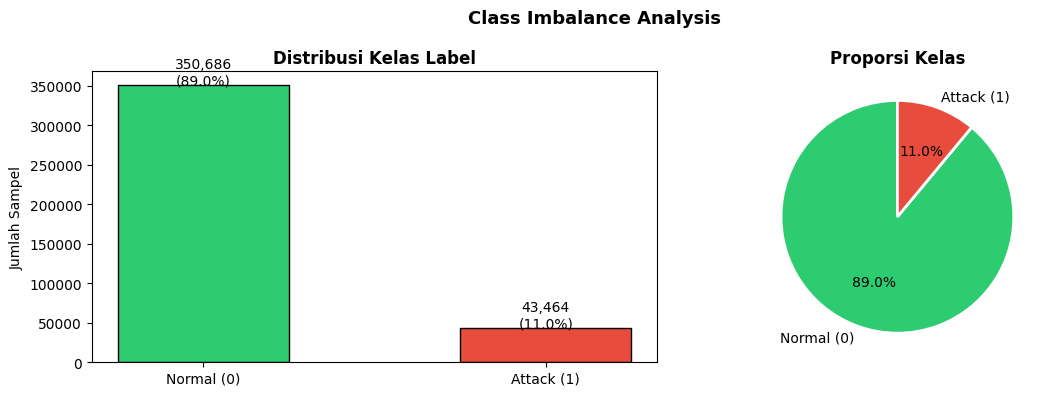

Rasio imbalance: 8.1:1 (Normal:Attack)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load train set untuk EDA (tidak gunakan test set)
df_train = pd.read_parquet('CUPID_train_raw.parquet')
X = df_train.drop(columns=['Label'])
y = df_train['Label']
print(f"Train dataset loaded: {df_train.shape}")

# EDA 1: DISTRIBUSI KELAS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = y.value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Normal (0)', 'Attack (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Kelas Label', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
axes[1].pie(counts.values, labels=['Normal (0)', 'Attack (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas', fontweight='bold')
plt.suptitle('Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Rasio imbalance: {counts[0]/counts[1]:.1f}:1 (Normal:Attack)")


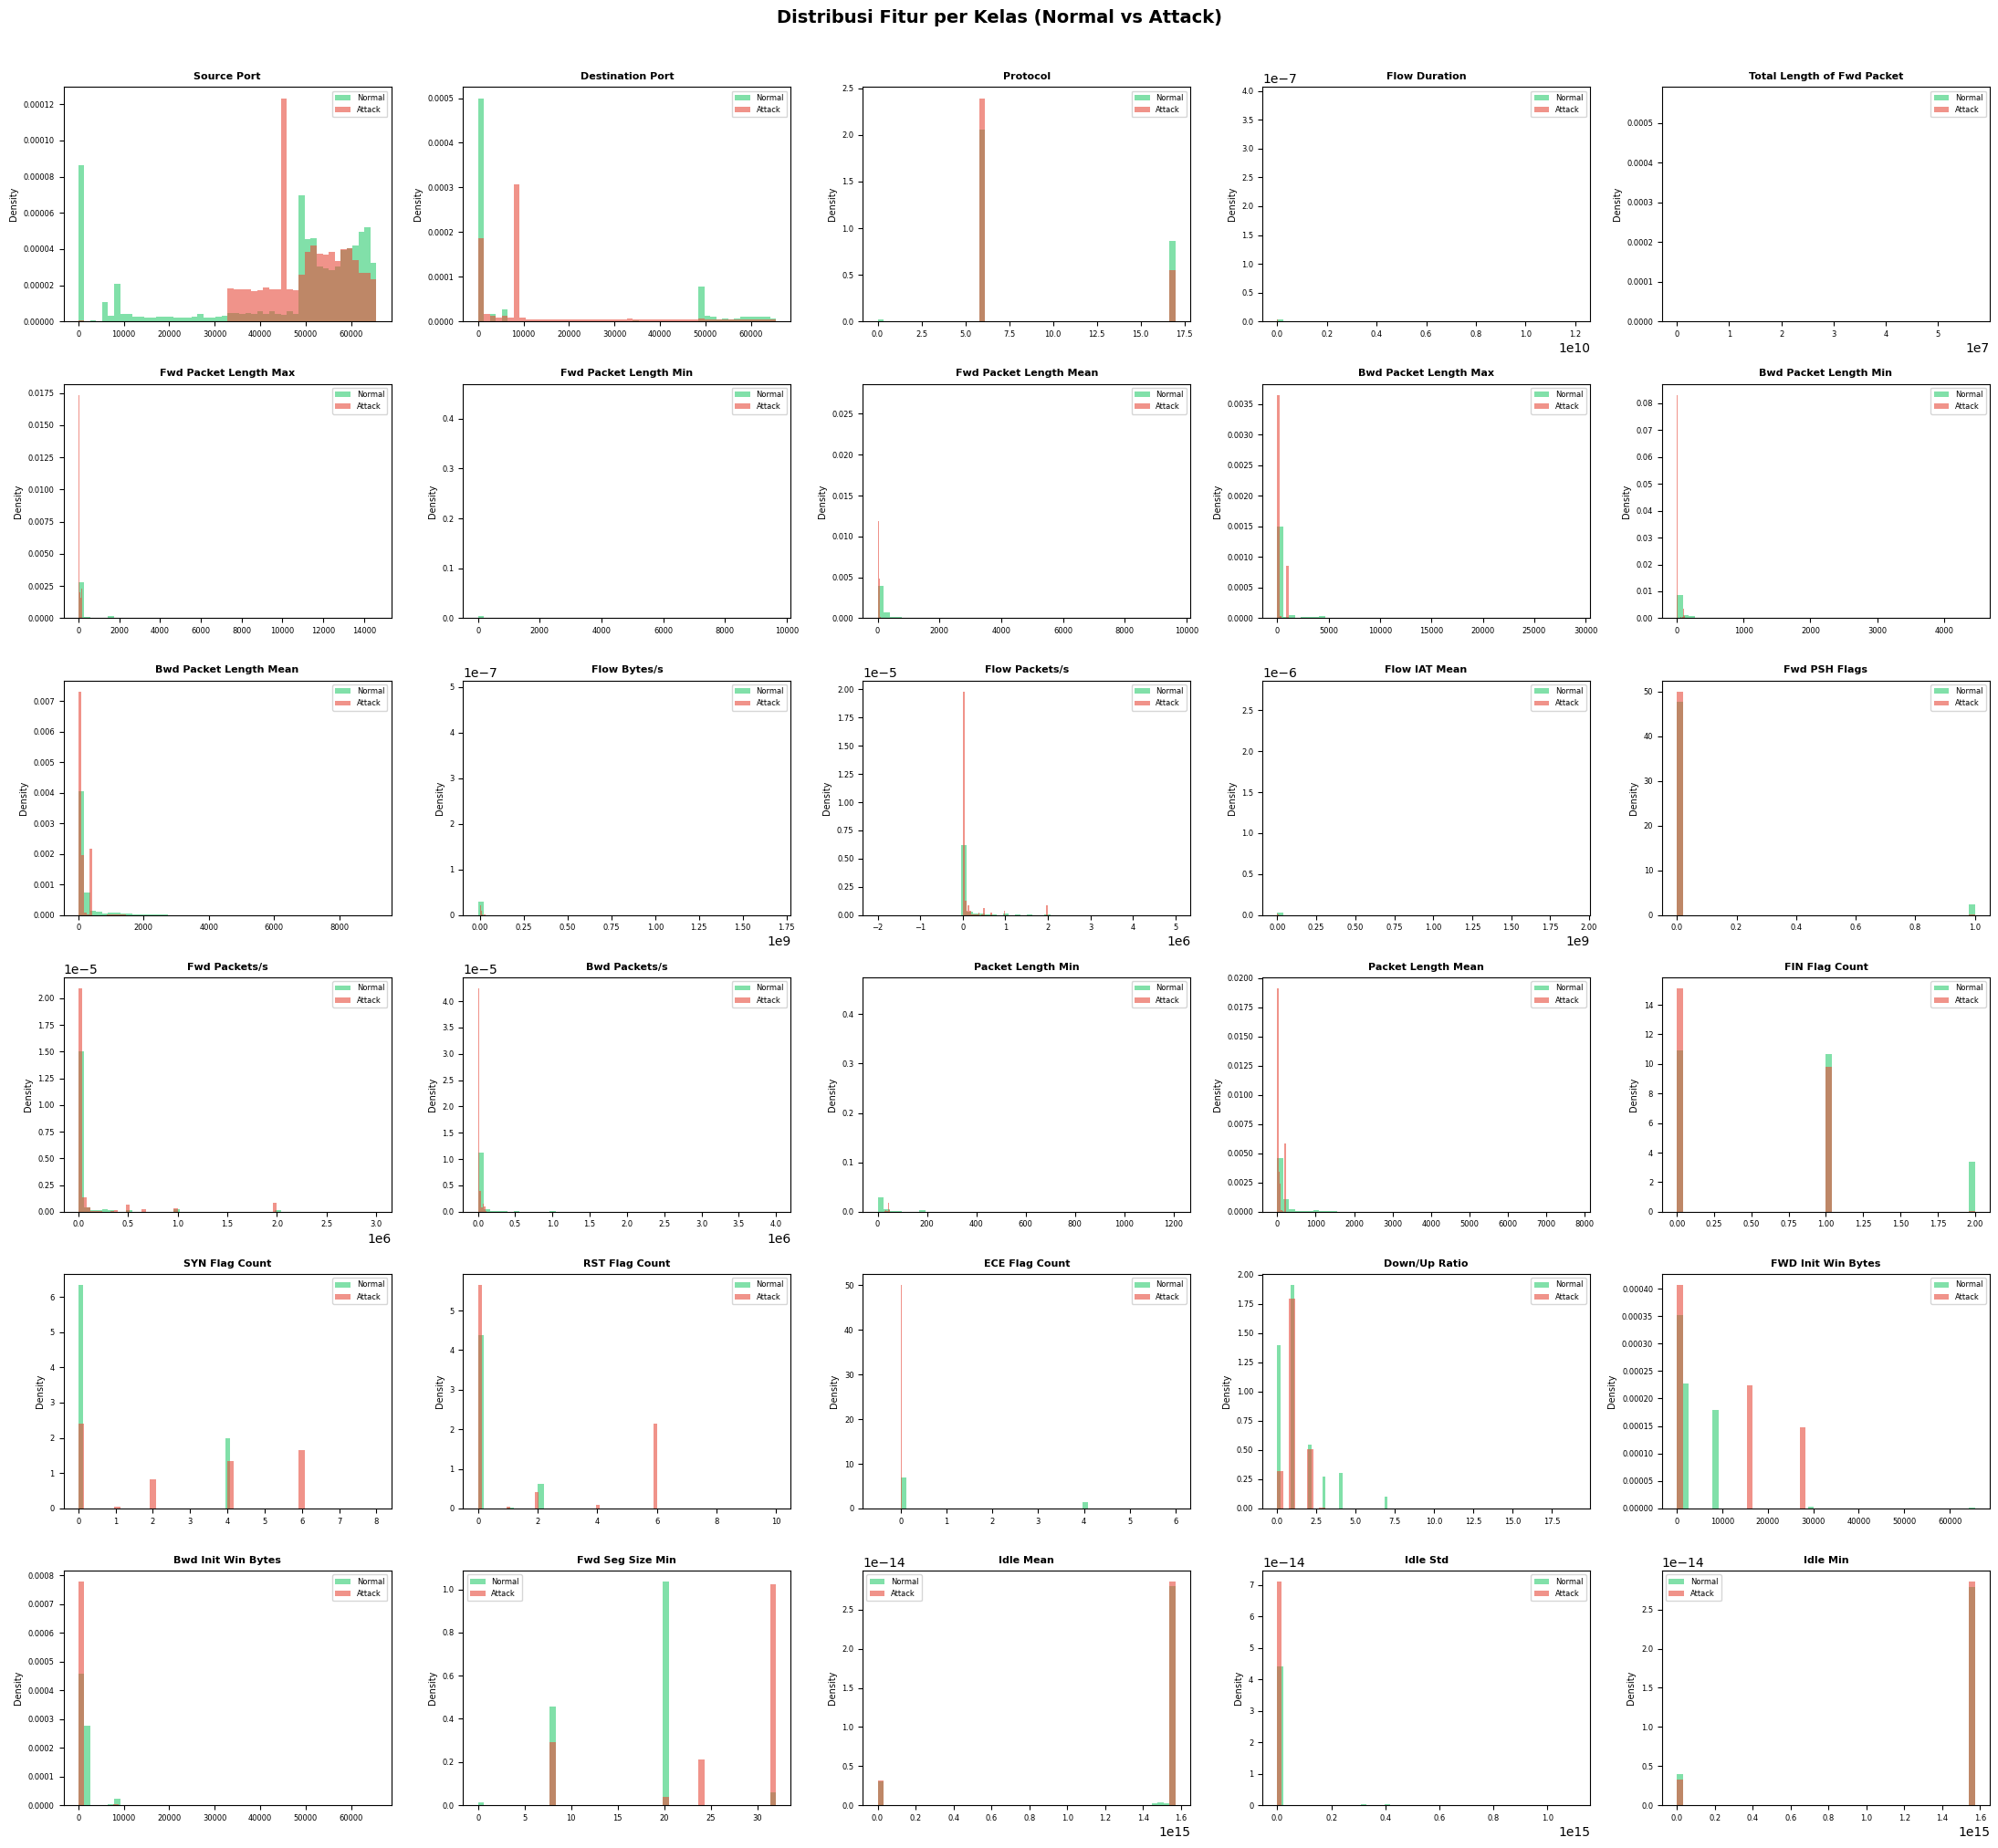

In [ ]:
# EDA 2: DISTRIBUSI 30 FITUR per kelas
df_normal = df_train[df_train['Label'] == 0]
df_attack = df_train[df_train['Label'] == 1]

fig, axes = plt.subplots(6, 5, figsize=(22, 20))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    ax = axes[i]
    ax.hist(df_normal[col], bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(df_attack[col], bins=50, alpha=0.6, color='#e74c3c', label='Attack', density=True)
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.set_ylabel('Density', fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)
plt.suptitle('Distribusi Fitur per Kelas (Normal vs Attack)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


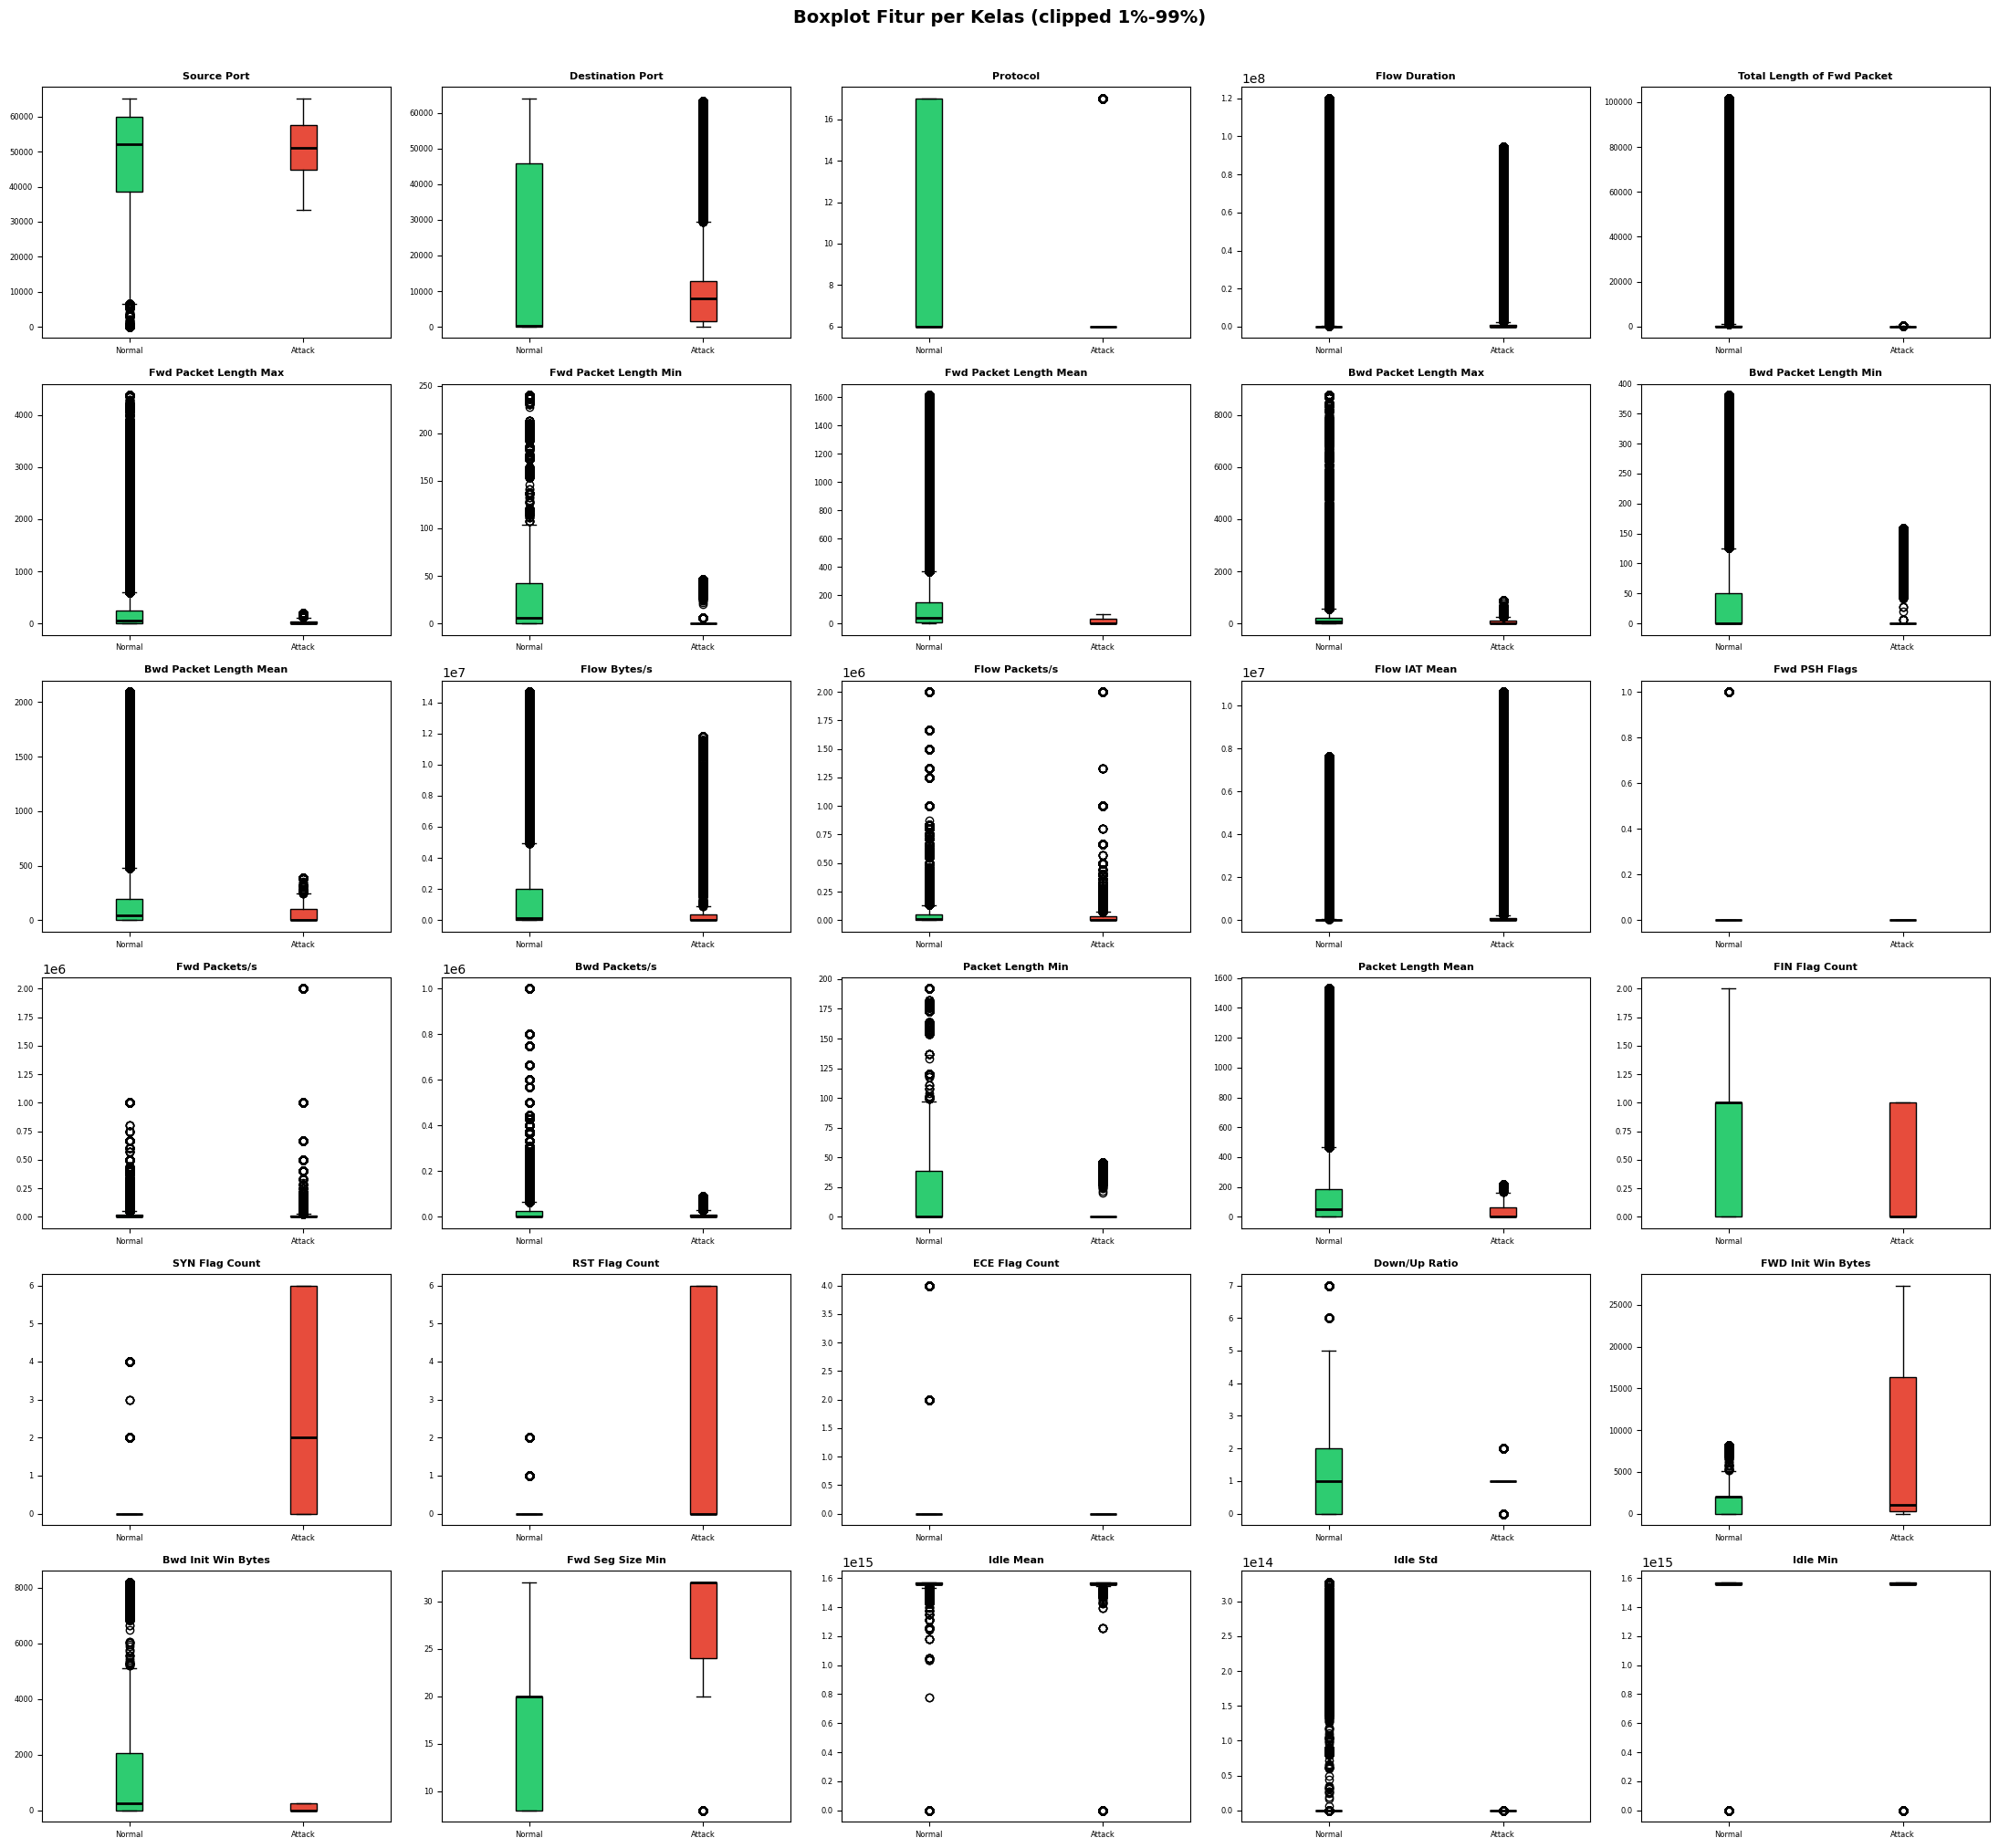

In [ ]:
# EDA 3: BOXPLOT
fig, axes = plt.subplots(6, 5, figsize=(22, 20))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    ax = axes[i]
    data_plot = [
        df_normal[col].clip(df_normal[col].quantile(0.01), df_normal[col].quantile(0.99)),
        df_attack[col].clip(df_attack[col].quantile(0.01), df_attack[col].quantile(0.99))
    ]
    bp = ax.boxplot(data_plot, labels=['Normal', 'Attack'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=6)
plt.suptitle('Boxplot Fitur per Kelas (clipped 1%-99%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


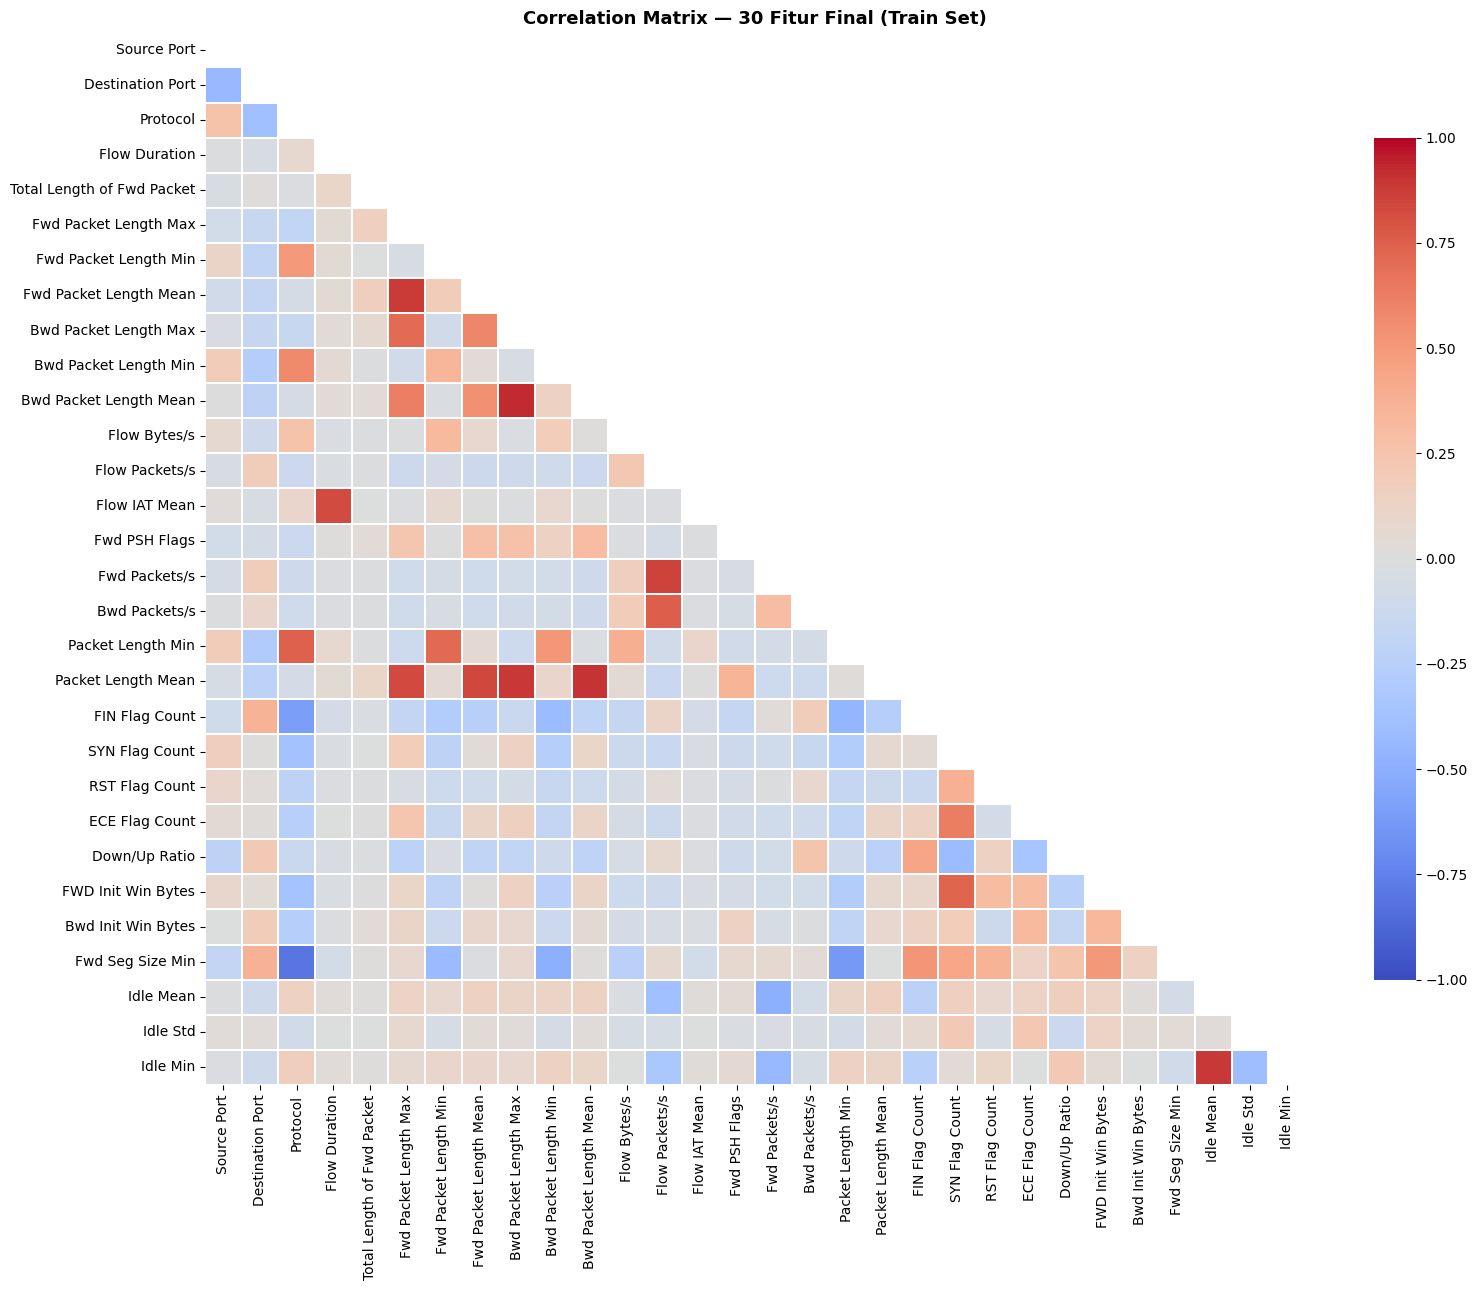


Pasangan fitur dengan |korelasi| > 0.7 yang masih tersisa:
  Bwd Packet Length Max ↔ Bwd Packet Length Mean : 0.925
  Bwd Packet Length Mean ↔ Packet Length Mean : 0.901
  Idle Mean ↔ Idle Min : 0.89
  Bwd Packet Length Max ↔ Packet Length Mean : 0.884
  Fwd Packet Length Max ↔ Fwd Packet Length Mean : 0.88
  Flow Packets/s ↔ Fwd Packets/s : 0.855
  Fwd Packet Length Mean ↔ Packet Length Mean : 0.837
  Fwd Packet Length Max ↔ Packet Length Mean : 0.828
  Flow Duration ↔ Flow IAT Mean : 0.825
  Protocol ↔ Fwd Seg Size Min : -0.812
  Flow Packets/s ↔ Bwd Packets/s : 0.753
  Protocol ↔ Packet Length Min : 0.743
  SYN Flag Count ↔ FWD Init Win Bytes : 0.732
  Fwd Packet Length Min ↔ Packet Length Min : 0.714
  Fwd Packet Length Max ↔ Bwd Packet Length Max : 0.707

Top 5 fitur paling diskriminatif:
                    Normal  Attack  Difference
Fwd Seg Size Min     0.524   0.818       0.293
SYN Flag Count       0.120   0.339       0.219
FIN Flag Count       0.350   0.199       0.151
RST Fl

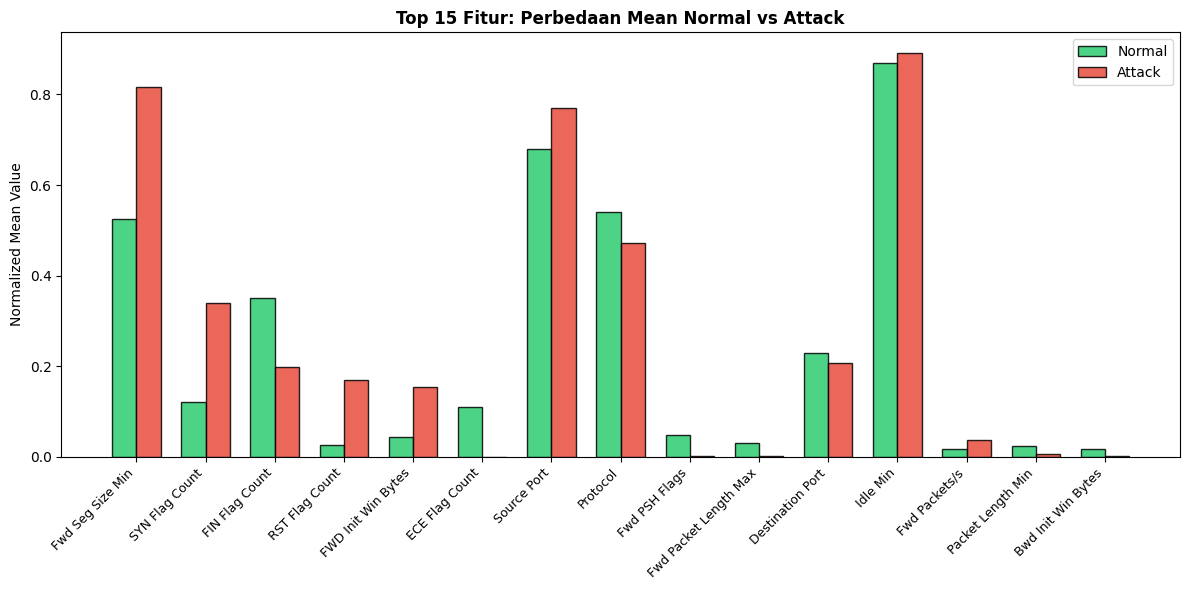

In [ ]:
# EDA 4: CORRELATION HEATMAP (dari train set)
plt.figure(figsize=(16, 13))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — 30 Fitur Final (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPasangan fitur dengan |korelasi| > 0.7 yang masih tersisa:")
high_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            high_pairs.append((corr.columns[i], corr.columns[j], round(val, 3)))
for pair in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} ↔ {pair[1]} : {pair[2]}")

# EDA 5: MEAN per kelas (normalized — dari train set saja)
from sklearn.preprocessing import MinMaxScaler
scaler_mm = MinMaxScaler()
X_norm = pd.DataFrame(scaler_mm.fit_transform(X), columns=X.columns)
X_norm['Label'] = y.values
mean_per_class = X_norm.groupby('Label').mean().T
mean_per_class.columns = ['Normal', 'Attack']
mean_per_class['Difference'] = abs(mean_per_class['Attack'] - mean_per_class['Normal'])
mean_per_class = mean_per_class.sort_values('Difference', ascending=False)
print("\nTop 5 fitur paling diskriminatif:")
print(mean_per_class.head(5).round(3))

top15 = mean_per_class.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top15))
width = 0.35
ax.bar(x_pos - width/2, top15['Normal'], width, label='Normal', color='#2ecc71', edgecolor='black', alpha=0.85)
ax.bar(x_pos + width/2, top15['Attack'], width, label='Attack',  color='#e74c3c', edgecolor='black', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(top15.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Mean Value')
ax.set_title('Top 15 Fitur: Perbedaan Mean Normal vs Attack', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_mean_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


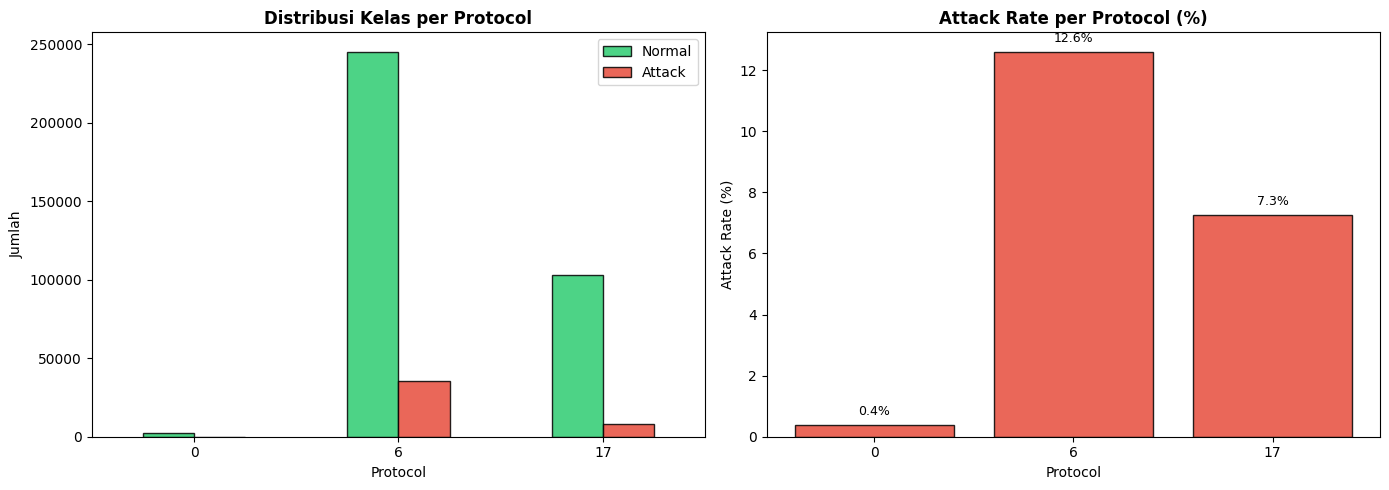


Protocol stats:
          Normal  Attack  Attack_Rate
Protocol                             
0           2504      10         0.40
6         245177   35375        12.61
17        103005    8079         7.27


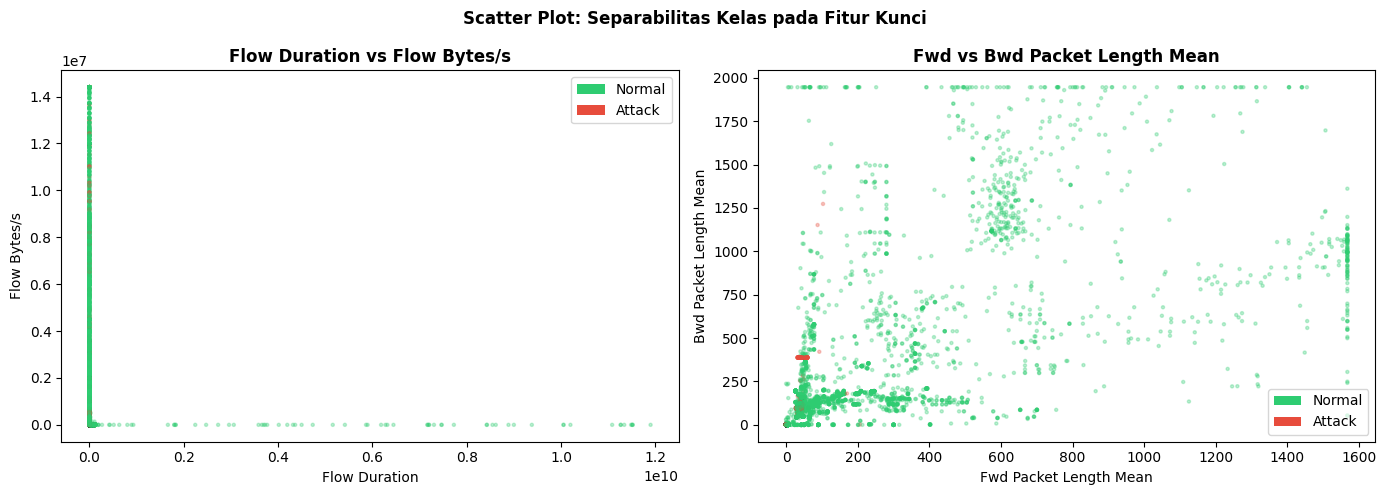

In [ ]:
# EDA 6: PROTOCOL ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
protocol_dist = df_train.groupby(['Protocol', 'Label']).size().unstack(fill_value=0)
protocol_dist.columns = ['Normal', 'Attack']
protocol_dist['Attack_Rate'] = protocol_dist['Attack'] / (protocol_dist['Normal'] + protocol_dist['Attack']) * 100
protocol_dist[['Normal', 'Attack']].plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Kelas per Protocol', fontweight='bold')
axes[0].set_xlabel('Protocol'); axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
axes[1].bar(protocol_dist.index.astype(str), protocol_dist['Attack_Rate'], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Attack Rate per Protocol (%)', fontweight='bold')
axes[1].set_xlabel('Protocol'); axes[1].set_ylabel('Attack Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(protocol_dist['Attack_Rate']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_06_protocol_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nProtocol stats:")
print(protocol_dist.round(2))

# EDA 7: SCATTER PLOT
sample_plot = df_train.sample(10000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {0: '#2ecc71', 1: '#e74c3c'}
colors_scatter = sample_plot['Label'].map(colors_map)
axes[0].scatter(sample_plot['Flow Duration'],
                sample_plot['Flow Bytes/s'].clip(0, sample_plot['Flow Bytes/s'].quantile(0.99)),
                c=colors_scatter, alpha=0.3, s=5)
axes[0].set_xlabel('Flow Duration'); axes[0].set_ylabel('Flow Bytes/s')
axes[0].set_title('Flow Duration vs Flow Bytes/s', fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Normal'), Patch(facecolor='#e74c3c', label='Attack')]
axes[0].legend(handles=legend_elements)
axes[1].scatter(
    sample_plot['Fwd Packet Length Mean'].clip(0, sample_plot['Fwd Packet Length Mean'].quantile(0.99)),
    sample_plot['Bwd Packet Length Mean'].clip(0, sample_plot['Bwd Packet Length Mean'].quantile(0.99)),
    c=colors_scatter, alpha=0.3, s=5)
axes[1].set_xlabel('Fwd Packet Length Mean'); axes[1].set_ylabel('Bwd Packet Length Mean')
axes[1].set_title('Fwd vs Bwd Packet Length Mean', fontweight='bold')
axes[1].legend(handles=legend_elements)
plt.suptitle('Scatter Plot: Separabilitas Kelas pada Fitur Kunci', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# 3. Feature Engineering

Semua fitur baru dibuat berdasarkan domain knowledge IDS.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_parquet('CUPID_train_raw.parquet')
df_test  = pd.read_parquet('CUPID_test_raw.parquet')

X_train = df_train.drop(columns=['Label'])
y_train = df_train['Label']
X_test  = df_test.drop(columns=['Label'])
y_test  = df_test['Label']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

def add_features(X):
    """Tambahkan fitur engineered ke DataFrame — tidak butuh statistik dari data lain.
    Semua operasi bersifat row-wise, sehingga aman diterapkan terpisah ke train & test."""
    X = X.copy()

    # FE 1 (PERBAIKAN): Fwd/Bwd Packet Length Ratio
    # Rasio rata-rata panjang paket forward vs backward.
    # Serangan satu arah (flood) punya rasio sangat tinggi.
    X['Fwd_Bwd_PktLen_Ratio'] = X['Fwd Packet Length Mean'] / (X['Bwd Packet Length Mean'] + 1)

    # FE 2: Packet Rate Ratio
    X['Pkt_Rate_Ratio'] = X['Fwd Packets/s'] / (X['Bwd Packets/s'] + 1)

    # FE 3: TCP Flag Score
    X['TCP_Flag_Score'] = (
        X['SYN Flag Count'] * 3 +
        X['RST Flag Count'] * 2 +
        X['FIN Flag Count'] * 1
    )

    # FE 4: Flow Intensity
    X['Flow_Intensity'] = X['Flow Bytes/s'] * X['Flow Duration']
    X['Flow_Intensity'] = X['Flow_Intensity'].replace([np.inf, -np.inf], 0).fillna(0)

    # FE 5: Window Size Ratio
    X['Win_Size_Ratio'] = X['FWD Init Win Bytes'] / (X['Bwd Init Win Bytes'] + 1)

    # FE 6: Forward Packet Length Spread
    X['Fwd_PktLen_Spread'] = X['Fwd Packet Length Max'] - X['Fwd Packet Length Min']

    # FE 7: Idle Ratio
    X['Idle_Ratio'] = X['Idle Mean'] / (X['Flow Duration'] + 1)
    X['Idle_Ratio'] = X['Idle_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

    return X

X_train = add_features(X_train)
X_test  = add_features(X_test)

new_features = ['Fwd_Bwd_PktLen_Ratio', 'Pkt_Rate_Ratio', 'TCP_Flag_Score',
                'Flow_Intensity', 'Win_Size_Ratio', 'Fwd_PktLen_Spread', 'Idle_Ratio']

print(f"\nFitur setelah FE (train): {X_train.shape[1]}")
print(f"Fitur baru             : {len(new_features)}")
print("\n✅ Fitur engineered diterapkan identik ke train & test (row-wise, no leakage)")


Train: (394150, 30) | Test: (98538, 30)

Fitur setelah FE (train): 37
Fitur baru             : 7

✅ Fitur engineered diterapkan identik ke train & test (row-wise, no leakage)


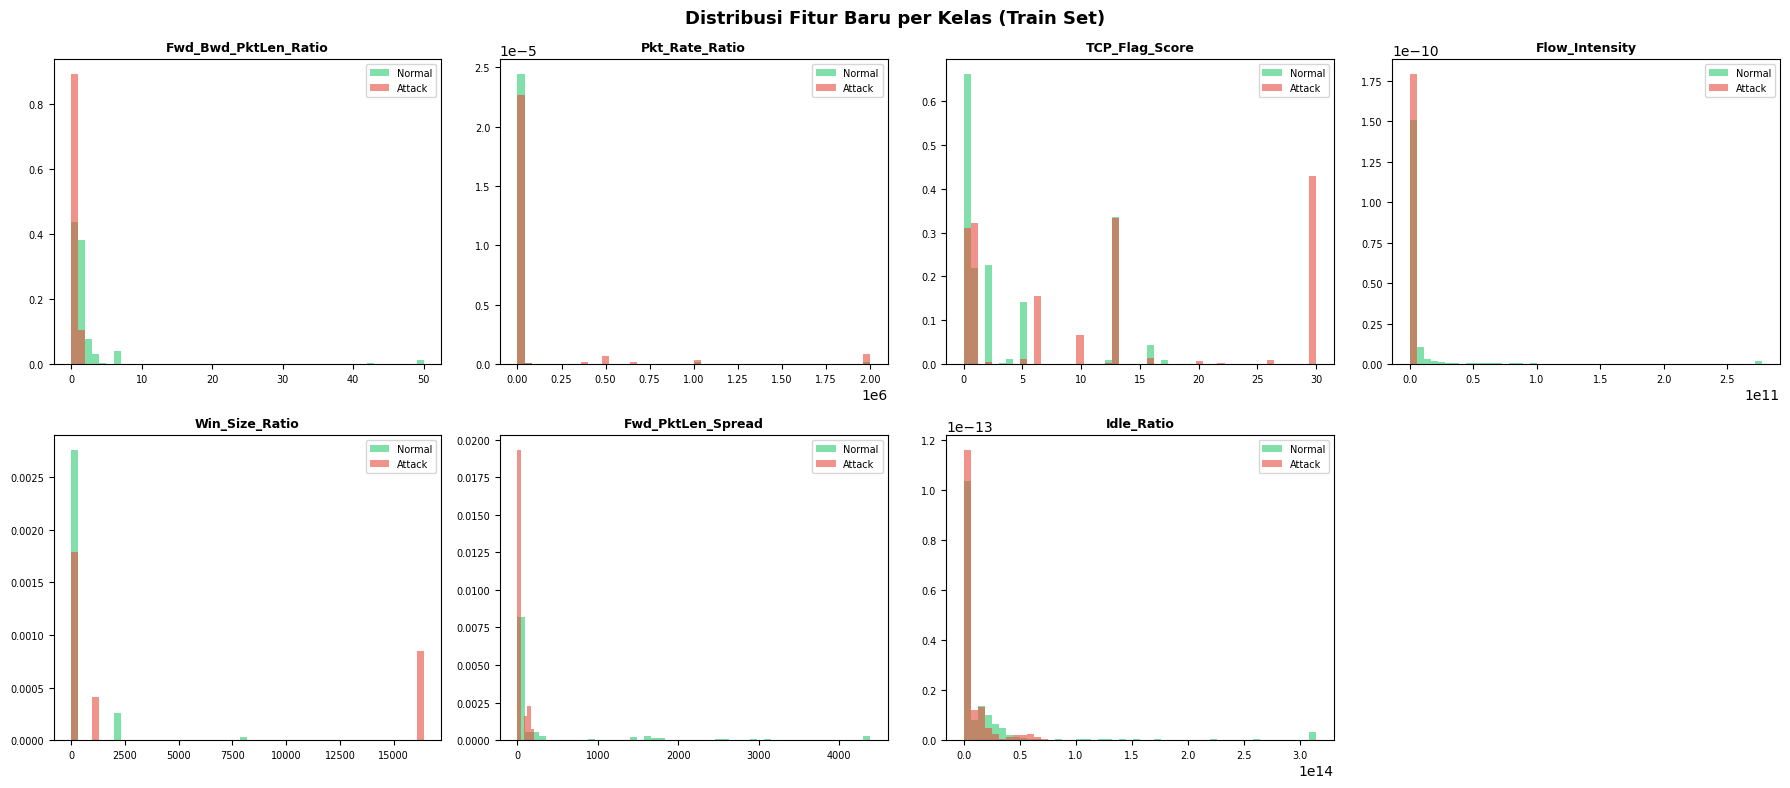


MEAN FITUR BARU PER KELAS (train set)
                       Mean_Normal   Mean_Attack   Ratio
Fwd_Bwd_PktLen_Ratio  3.570100e+00  2.877000e-01   0.081
Pkt_Rate_Ratio        2.367982e+04  1.006026e+05   4.248
TCP_Flag_Score        4.080000e+00  1.189970e+01   2.917
Flow_Intensity        2.953641e+10  8.263455e+08   0.028
Win_Size_Ratio        2.839675e+02  4.715882e+03  16.607
Fwd_PktLen_Spread     4.103207e+02  3.193260e+01   0.078
Idle_Ratio            1.994852e+13  7.619223e+12   0.382

Disimpan: CUPID_train_fe.parquet → (394150, 37)
Disimpan: CUPID_test_fe.parquet  → (98538, 37)


In [ ]:
# Visualisasi distribusi fitur baru (dari train set)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(new_features):
    ax = axes[i]
    clip_99 = X_train[col].quantile(0.99)
    clip_01 = X_train[col].quantile(0.01)
    ax.hist(X_train.loc[y_train==0, col].clip(clip_01, clip_99),
            bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(X_train.loc[y_train==1, col].clip(clip_01, clip_99),
            bins=50, alpha=0.6, color='#e74c3c', label='Attack', density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Baru per Kelas (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fe_new_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Validasi mean comparison
print("\n" + "="*60)
print("MEAN FITUR BARU PER KELAS (train set)")
print("="*60)
fe_comparison = pd.DataFrame({
    'Mean_Normal': X_train.loc[y_train==0, new_features].mean(),
    'Mean_Attack': X_train.loc[y_train==1, new_features].mean(),
})
fe_comparison['Ratio'] = (fe_comparison['Mean_Attack'] / (fe_comparison['Mean_Normal'] + 1e-9)).round(3)
print(fe_comparison.round(4))

# Simpan
pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1).to_parquet('CUPID_train_fe.parquet', index=False)
pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1).to_parquet('CUPID_test_fe.parquet',  index=False)
print(f"\nDisimpan: CUPID_train_fe.parquet → {X_train.shape}")
print(f"Disimpan: CUPID_test_fe.parquet  → {X_test.shape}")


# 4. Feature Importance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_parquet('CUPID_train_fe.parquet')
X_train  = df_train.drop(columns=['Label'])
y_train  = df_train['Label']
print(f"Train loaded: {df_train.shape} | Total fitur: {X_train.shape[1]}")

# Metode 1: Mutual Information
print("\n" + "="*60)
print("METODE 1: MUTUAL INFORMATION (subsample 50k dari train)")
print("="*60)

idx_sample = np.random.choice(len(X_train), size=50000, replace=False)
X_mi = X_train.iloc[idx_sample]
y_mi = y_train.iloc[idx_sample]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores}) \
          .sort_values('MI_Score', ascending=False).reset_index(drop=True)
print("Top 20 fitur berdasarkan Mutual Information:")
print(mi_df.head(20).to_string())

# Metode 2: Random Forest Importance
print("\n" + "="*60)
print("METODE 2: RANDOM FOREST IMPORTANCE (subsample 100k dari train)")
print("="*60)

idx_rf = np.random.choice(len(X_train), size=100000, replace=False)
X_rf = X_train.iloc[idx_rf]
y_rf = y_train.iloc[idx_rf]

rf = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced',
                             n_jobs=-1, random_state=42)
rf.fit(X_rf, y_rf)

rf_importance = pd.DataFrame({'Feature': X_train.columns, 'RF_Importance': rf.feature_importances_}) \
                  .sort_values('RF_Importance', ascending=False).reset_index(drop=True)
print("Top 20 fitur berdasarkan Random Forest:")
print(rf_importance.head(20).to_string())

# Ranking Konsensus
print("\n" + "="*60)
print("RANKING KONSENSUS (MI + RF)")
print("="*60)

mi_df['MI_Rank'] = mi_df['MI_Score'].rank(ascending=False)
rf_importance['RF_Rank'] = rf_importance['RF_Importance'].rank(ascending=False)

consensus = mi_df.merge(rf_importance, on='Feature')
consensus['Avg_Rank'] = (consensus['MI_Rank'] + consensus['RF_Rank']) / 2
consensus = consensus.sort_values('Avg_Rank').reset_index(drop=True)
consensus['Consensus_Rank'] = consensus.index + 1

engineered_feats = ['Fwd_Bwd_PktLen_Ratio', 'Pkt_Rate_Ratio', 'TCP_Flag_Score',
                    'Flow_Intensity', 'Win_Size_Ratio', 'Fwd_PktLen_Spread', 'Idle_Ratio']
consensus['Is_Engineered'] = consensus['Feature'].isin(engineered_feats)

print(consensus[['Feature', 'MI_Score', 'RF_Importance', 'MI_Rank', 'RF_Rank', 'Avg_Rank']].head(20).round(4).to_string())
consensus.to_csv('feature_importance_consensus.csv', index=False)
print("\nDisimpan: feature_importance_consensus.csv")


Train loaded: (394150, 38) | Total fitur: 37

METODE 1: MUTUAL INFORMATION (subsample 50k dari train)
Top 20 fitur berdasarkan Mutual Information:
                       Feature  MI_Score
0               Win_Size_Ratio  0.271862
1           Packet Length Mean  0.262676
2           FWD Init Win Bytes  0.249210
3         Fwd_Bwd_PktLen_Ratio  0.245038
4        Fwd Packet Length Max  0.240462
5   Total Length of Fwd Packet  0.231764
6                     Idle Min  0.230108
7       Fwd Packet Length Mean  0.226804
8                    Idle Mean  0.226677
9             Destination Port  0.210804
10              Flow_Intensity  0.208945
11            Fwd Seg Size Min  0.197815
12                  Idle_Ratio  0.187220
13              Pkt_Rate_Ratio  0.181511
14                Flow Bytes/s  0.174946
15          Bwd Init Win Bytes  0.154512
16              Flow Packets/s  0.140922
17      Bwd Packet Length Mean  0.139466
18               Fwd Packets/s  0.136525
19               Flow IAT Mean  0

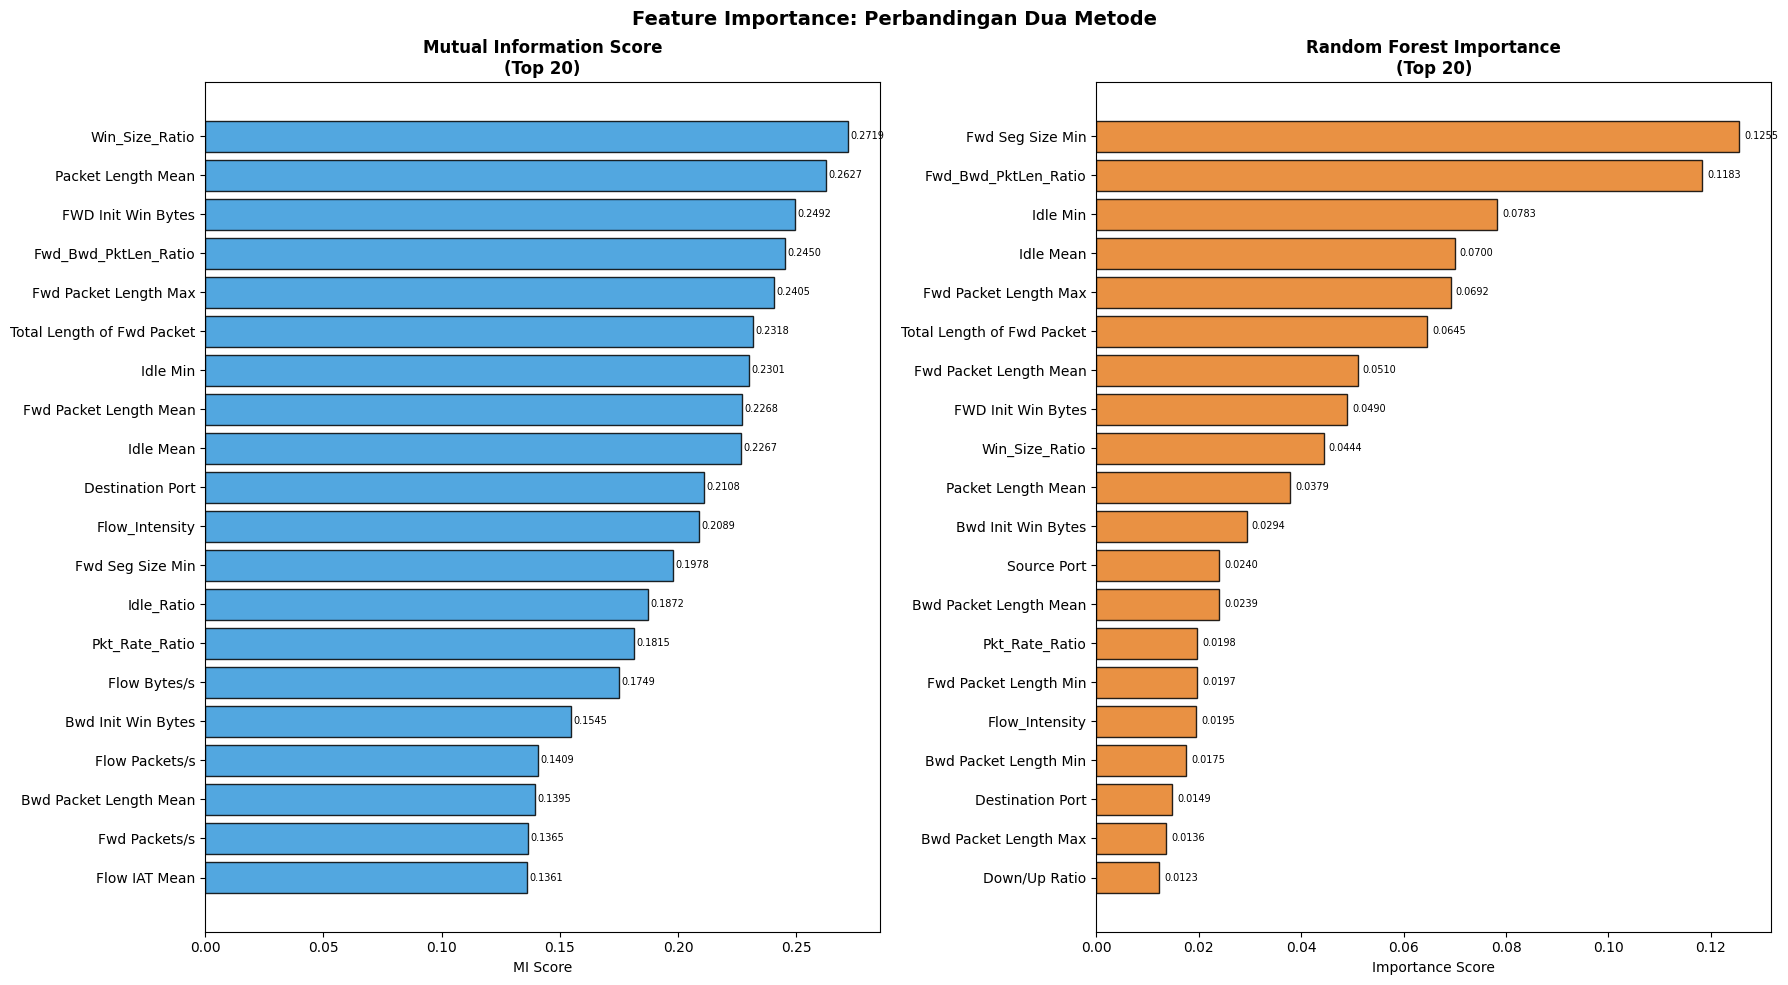


Posisi Fitur Engineered di Ranking Konsensus:
                 Feature  Consensus_Rank  MI_Score  RF_Importance
0   Fwd_Bwd_PktLen_Ratio               1    0.2450         0.1183
1         Win_Size_Ratio               2    0.2719         0.0444
10        Flow_Intensity              11    0.2089         0.0195
13        Pkt_Rate_Ratio              14    0.1815         0.0198
18            Idle_Ratio              19    0.1872         0.0060
21        TCP_Flag_Score              22    0.1265         0.0098
30     Fwd_PktLen_Spread              31    0.1141         0.0034

Top 5 konsensus:
   1. Fwd_Bwd_PktLen_Ratio ← [ENGINEERED]
   2. Win_Size_Ratio ← [ENGINEERED]
   3. Idle Min
   4. Fwd Packet Length Max
   5. FWD Init Win Bytes


In [ ]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
top_n = 20
mi_top = mi_df.head(top_n).sort_values('MI_Score')
bars1 = axes[0].barh(mi_top['Feature'], mi_top['MI_Score'], color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Mutual Information Score\n(Top 20)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('MI Score')
for bar, val in zip(bars1, mi_top['MI_Score']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=7)
rf_top = rf_importance.head(top_n).sort_values('RF_Importance')
bars2 = axes[1].barh(rf_top['Feature'], rf_top['RF_Importance'], color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('Random Forest Importance\n(Top 20)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Score')
for bar, val in zip(bars2, rf_top['RF_Importance']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=7)
plt.suptitle('Feature Importance: Perbandingan Dua Metode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPosisi Fitur Engineered di Ranking Konsensus:")
fe_in_consensus = consensus[consensus['Is_Engineered']][
    ['Feature', 'Consensus_Rank', 'MI_Score', 'RF_Importance']].sort_values('Consensus_Rank')
print(fe_in_consensus.round(4).to_string())

print("\nTop 5 konsensus:")
for _, row in consensus.head(5).iterrows():
    tag = " ← [ENGINEERED]" if row['Is_Engineered'] else ""
    print(f"  {int(row['Consensus_Rank']):2d}. {row['Feature']}{tag}")


# Finalisasi Dataset untuk UAS

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_parquet('CUPID_train_fe.parquet')
df_test  = pd.read_parquet('CUPID_test_fe.parquet')

X_train = df_train.drop(columns=['Label']); y_train = df_train['Label']
X_test  = df_test.drop(columns=['Label']);  y_test  = df_test['Label']

consensus = pd.read_csv('feature_importance_consensus.csv')
top15_features = consensus.head(15)['Feature'].tolist()

print("15 Fitur Final untuk UAS:")
engineered_feats = ['Fwd_Bwd_PktLen_Ratio', 'Pkt_Rate_Ratio', 'TCP_Flag_Score',
                    'Flow_Intensity', 'Win_Size_Ratio', 'Fwd_PktLen_Spread', 'Idle_Ratio']
for i, f in enumerate(top15_features, 1):
    tag = " [ENGINEERED]" if f in engineered_feats else ""
    print(f"  {i:2d}. {f}{tag}")

missing_feats = [f for f in top15_features if f not in X_train.columns]
if missing_feats:
    print(f"\nWARNING: Fitur tidak ditemukan: {missing_feats}")
else:
    print("\nSemua fitur tersedia. ✅")

X_train_final = X_train[top15_features]
X_test_final  = X_test[top15_features]

# FIX #1 (diperkuat): Fit scaler HANYA pada train, transform test terpisah
scaler_final = RobustScaler()
X_train_scaled = pd.DataFrame(scaler_final.fit_transform(X_train_final),
                               columns=X_train_final.columns)
X_test_scaled  = pd.DataFrame(scaler_final.transform(X_test_final),
                               columns=X_test_final.columns)

joblib.dump(scaler_final, 'scaler_final.joblib')
joblib.dump(top15_features, 'feature_names.joblib')
print("\nScaler dan feature names disimpan.")

# Simpan dataset final (train & test terpisah)
pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1).to_parquet('CUPID_final_train_scaled.parquet', index=False)
pd.concat([X_test_scaled,  y_test.reset_index(drop=True)],  axis=1).to_parquet('CUPID_final_test_scaled.parquet',  index=False)

# Simpan juga raw untuk interpretasi
pd.concat([X_train_final.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1).to_parquet('CUPID_final_train_raw.parquet', index=False)
pd.concat([X_test_final.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1).to_parquet('CUPID_final_test_raw.parquet',  index=False)

print(f"\nDisimpan: CUPID_final_train_scaled.parquet → {X_train_scaled.shape}")
print(f"Disimpan: CUPID_final_test_scaled.parquet  → {X_test_scaled.shape}")

print("\n" + "="*60)
print("RINGKASAN PIPELINE UTS — SIAP UNTUK UAS")
print("="*60)
print(f"Baris awal  : 1,452,037")
print(f"Train set   : {len(X_train_scaled):,}")
print(f"Test set    : {len(X_test_scaled):,}")
print(f"Fitur awal  : 83")
print(f"Fitur final : {X_train_scaled.shape[1]}")
print(f"\nFile tersimpan:")
print(f"  - CUPID_final_train_scaled.parquet  (train 15 fitur, scaled)")
print(f"  - CUPID_final_test_scaled.parquet   (test  15 fitur, scaled)")
print(f"  - CUPID_final_train_raw.parquet     (train 15 fitur, raw)")
print(f"  - CUPID_final_test_raw.parquet      (test  15 fitur, raw)")
print(f"  - scaler_final.joblib               (RobustScaler fit on train only ✅)")
print(f"  - feature_names.joblib")
print(f"  - feature_importance_consensus.csv")


15 Fitur Final untuk UAS:
   1. Fwd_Bwd_PktLen_Ratio [ENGINEERED]
   2. Win_Size_Ratio [ENGINEERED]
   3. Idle Min
   4. Fwd Packet Length Max
   5. FWD Init Win Bytes
   6. Packet Length Mean
   7. Total Length of Fwd Packet
   8. Idle Mean
   9. Fwd Seg Size Min
  10. Fwd Packet Length Mean
  11. Flow_Intensity [ENGINEERED]
  12. Bwd Init Win Bytes
  13. Destination Port
  14. Pkt_Rate_Ratio [ENGINEERED]
  15. Bwd Packet Length Mean

Semua fitur tersedia. ✅

Scaler dan feature names disimpan.

Disimpan: CUPID_final_train_scaled.parquet → (394150, 15)
Disimpan: CUPID_final_test_scaled.parquet  → (98538, 15)

RINGKASAN PIPELINE UTS — SIAP UNTUK UAS
Baris awal  : 1,452,037
Train set   : 394,150
Test set    : 98,538
Fitur awal  : 83
Fitur final : 15

File tersimpan:
  - CUPID_final_train_scaled.parquet  (train 15 fitur, scaled)
  - CUPID_final_test_scaled.parquet   (test  15 fitur, scaled)
  - CUPID_final_train_raw.parquet     (train 15 fitur, raw)
  - CUPID_final_test_raw.parquet      (

# UJIAN AKHIR SEMESTER (UAS)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data final — train & test sudah terpisah dengan benar
df_train = pd.read_parquet('CUPID_final_train_scaled.parquet')
df_test  = pd.read_parquet('CUPID_final_test_scaled.parquet')

X_train = df_train.drop(columns=['Label']); y_train = df_train['Label']
X_test  = df_test.drop(columns=['Label']);  y_test  = df_test['Label']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribusi kelas (train):\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nDistribusi kelas (test):\n{y_test.value_counts(normalize=True).mul(100).round(2)}")


Train: (394150, 15) | Test: (98538, 15)
Distribusi kelas (train):
Label
0    88.97
1    11.03
Name: proportion, dtype: float64

Distribusi kelas (test):
Label
0    88.97
1    11.03
Name: proportion, dtype: float64


In [ ]:
# FIX #7: Gunakan average='weighted' untuk metrik yang lebih representatif
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, evaluasi, return dict hasil."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    res = {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1'       : round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_te, y_prob), 4) if y_prob is not None else '-',
    }
    print(f"  {name}: Acc={res['Accuracy']} | F1={res['F1']} | AUC={res['ROC_AUC']}")
    return res, model.predict(X_te), (y_prob if y_prob is not None else None)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

# Definisi 5 model baseline
models_def = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                             n_jobs=-1, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                                   eval_metric='logloss', n_jobs=-1,
                                   random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                                    n_jobs=-1, random_state=42, verbose=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50,
                         early_stopping=True, random_state=42),
}

print("\n" + "="*60)
print("BASELINE TRAINING & EVALUASI (semua model pada full train set)")
print("="*60)

# FIX #5: KNN & MLP juga dilatih di FULL train set agar apple-to-apple
# Untuk KNN large dataset, kita pakai subset strategis (300k) agar tidak OOM,
# tapi konsisten satu subsetting untuk SEMUA model jika resource terbatas.
# Di sini kita latih di full train, user bisa sesuaikan dengan RAM yang tersedia.

baseline_results = {}
baseline_preds   = {}
baseline_probs   = {}

for name, model in models_def.items():
    print(f"\nTraining {name}...")
    res, y_pred, y_prob = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    baseline_results[name] = res
    baseline_preds[name]   = y_pred
    baseline_probs[name]   = y_prob
    joblib.dump(model, f'model_{name.replace(" ","_").lower()}_baseline.joblib')

# FIX #4: Simpan baseline AKTUAL (bukan hardcode)
baseline_df = pd.DataFrame(baseline_results).T
print("\n" + "="*60)
print("TABEL BASELINE AKTUAL")
print("="*60)
print(baseline_df.to_string())


scale_pos_weight: 8.07

BASELINE TRAINING & EVALUASI (semua model pada full train set)

Training Random Forest...
  Random Forest: Acc=0.9982 | F1=0.9982 | AUC=0.9999

Training XGBoost...
  XGBoost: Acc=0.9974 | F1=0.9974 | AUC=0.9999

Training LightGBM...
  LightGBM: Acc=0.9952 | F1=0.9952 | AUC=0.9999

Training KNN...
  KNN: Acc=0.9957 | F1=0.9957 | AUC=0.9972

Training MLP...
  MLP: Acc=0.9826 | F1=0.982 | AUC=0.9966

TABEL BASELINE AKTUAL
               Accuracy  Precision  Recall      F1  ROC_AUC
Random Forest    0.9982     0.9982  0.9982  0.9982   0.9999
XGBoost          0.9974     0.9974  0.9974  0.9974   0.9999
LightGBM         0.9952     0.9953  0.9952  0.9952   0.9999
KNN              0.9957     0.9957  0.9957  0.9957   0.9972
MLP              0.9826     0.9828  0.9826  0.9820   0.9966


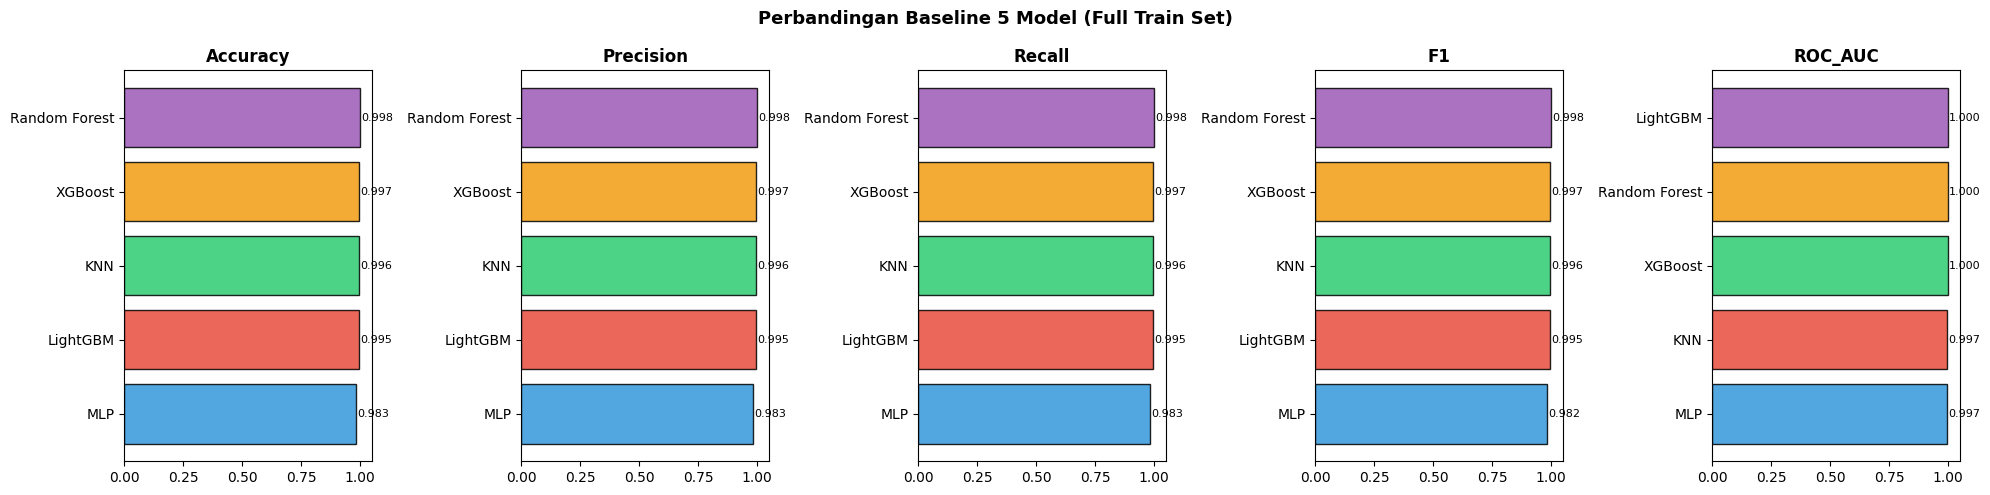

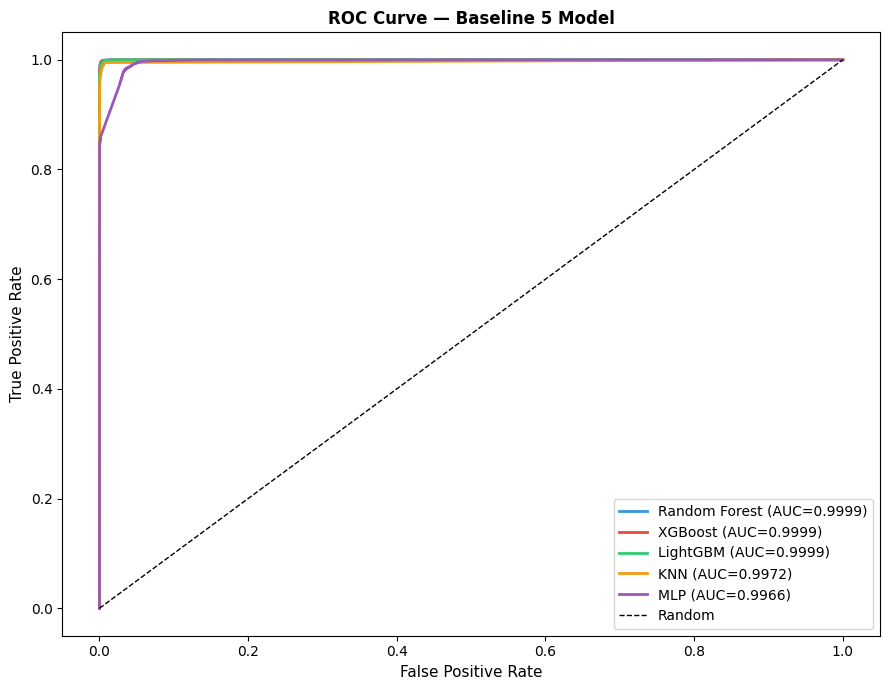

In [ ]:
# Visualisasi Baseline
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
bl_plot = baseline_df.copy()
bl_plot = bl_plot[bl_plot['ROC_AUC'] != '-'].astype(float)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for i, metric in enumerate(metrics):
    vals = bl_plot[metric].sort_values()
    bars = axes[i].barh(vals.index, vals.values, color=colors_bar[:len(vals)],
                         edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlim(0, 1.05)
    for bar, val in zip(bars, vals.values):
        axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=8)
plt.suptitle('Perbandingan Baseline 5 Model (Full Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelling_01_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve Baseline
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for (name, _), color in zip(models_def.items(), colors_roc):
    if baseline_probs[name] is not None:
        fpr, tpr, _ = roc_curve(y_test, baseline_probs[name])
        auc = roc_auc_score(y_test, baseline_probs[name])
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Baseline 5 Model', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('modelling_02_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


# Hyperparameter Tuning

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.3 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Subsample 50k hanya untuk tahap PENCARIAN hyperparameter (lebih cepat).
# Setelah best params ditemukan, model dilatih ulang di FULL train set.
from sklearn.model_selection import train_test_split as tts
X_tune, _, y_tune, _ = tts(X_train, y_train, train_size=50_000,
                             stratify=y_train, random_state=42)
scale_pos_tune = (y_tune == 0).sum() / (y_tune == 1).sum()

print(f"Data tuning (hyperparameter search) : {X_tune.shape}")
print(f"Data training final (full)          : {X_train.shape}")
print(f"scale_pos_weight                    : {scale_pos_tune:.2f}")
print("\nNote: Tuning menggunakan Optuna di 50k, lalu best model dilatih ulang di full train set.")

Data tuning (hyperparameter search) : (50000, 15)
Data training final (full)          : (394150, 15)
scale_pos_weight                    : 8.07

Note: tuning cepat di 50k, lalu best model dilatih ulang di full train set.


In [ ]:
# TUNING RANDOM FOREST
print("\n" + "="*50)
print("TUNING: RANDOM FOREST (OPTUNA)")
print("="*50)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200]),
        'max_depth': trial.suggest_categorical('max_depth', [10, 20, None]),
        'min_samples_split': trial.suggest_categorical('min_samples_split', [2, 5]),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced',
        'n_jobs': -1,
        'random_state': 42
    }

    rf = RandomForestClassifier(**params)
    # Validasi cv=2 sesuai dengan kode awal agar komputasi tidak terlalu berat
    score = cross_val_score(rf, X_tune, y_tune, cv=2, scoring='f1_weighted', n_jobs=-1).mean()
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING) # Supress log agar rapi
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10) # 10 iterasi setara kode lama

print(f"Best params: {study_rf.best_params}")

# Re-train di full train set dengan parameter terbaik
rf_best = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', n_jobs=-1, random_state=42)
rf_best.fit(X_train, y_train)

y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

rf_res = {
    'Accuracy' : round(accuracy_score(y_test, y_pred_rf), 4),
    'Precision': round(precision_score(y_test, y_pred_rf, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred_rf, average='weighted', zero_division=0), 4),
    'F1'       : round(f1_score(y_test, y_pred_rf, average='weighted', zero_division=0), 4),
    'ROC_AUC'  : round(roc_auc_score(y_test, y_prob_rf), 4),
}
print(f"RF Tuned (full train): {rf_res}")
joblib.dump(rf_best, 'model_rf_tuned.joblib')


TUNING: RANDOM FOREST
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
RF Tuned (full train): {'Accuracy': 0.9976, 'Precision': 0.9976, 'Recall': 0.9976, 'F1': 0.9976, 'ROC_AUC': np.float64(0.9999)}


['model_rf_tuned.joblib']

In [ ]:
# TUNING XGBOOST
print("\n" + "="*50)
print("TUNING: XGBOOST (OPTUNA)")
print("="*50)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.05, 0.1, 0.2]),
        'max_depth': trial.suggest_categorical('max_depth', [4, 6, 8]),
        'subsample': trial.suggest_categorical('subsample', [0.8, 1.0]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.8, 1.0]),
        'scale_pos_weight': scale_pos_tune,
        'eval_metric': 'logloss',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0
    }

    xgb_model = xgb.XGBClassifier(**params)
    score = cross_val_score(xgb_model, X_tune, y_tune, cv=2, scoring='f1_weighted', n_jobs=-1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)

print(f"Best params: {study_xgb.best_params}")

# Re-train di full train set
scale_pos_full = (y_train == 0).sum() / (y_train == 1).sum()
best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'scale_pos_weight': scale_pos_full, 'eval_metric': 'logloss',
    'n_jobs': -1, 'random_state': 42, 'verbosity': 0
})

xgb_best = xgb.XGBClassifier(**best_xgb_params)
xgb_best.fit(X_train, y_train)

y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

xgb_res = {
    'Accuracy' : round(accuracy_score(y_test, y_pred_xgb), 4),
    'Precision': round(precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0), 4),
    'F1'       : round(f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0), 4),
    'ROC_AUC'  : round(roc_auc_score(y_test, y_prob_xgb), 4),
}
print(f"XGB Tuned (full train): {xgb_res}")
joblib.dump(xgb_best, 'model_xgb_tuned.joblib')


TUNING: XGBOOST
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGB Tuned (full train): {'Accuracy': 0.9971, 'Precision': 0.9971, 'Recall': 0.9971, 'F1': 0.9971, 'ROC_AUC': np.float64(0.9999)}


['model_xgb_tuned.joblib']

In [ ]:
# TUNING LIGHTGBM
print("\n" + "="*50)
print("TUNING: LIGHTGBM (OPTUNA)")
print("="*50)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.05, 0.1]),
        'max_depth': trial.suggest_categorical('max_depth', [8, -1]),
        'num_leaves': trial.suggest_categorical('num_leaves', [31, 63]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.8, 1.0]),
        'class_weight': 'balanced',
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1
    }

    lgb_model = lgb.LGBMClassifier(**params)
    score = cross_val_score(lgb_model, X_tune, y_tune, cv=2, scoring='f1_weighted', n_jobs=-1).mean()
    return score

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=10)

print(f"Best params: {study_lgb.best_params}")

# Re-train di full train set
best_lgb_params = study_lgb.best_params
best_lgb_params.update({'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42, 'verbose': -1})

lgb_best = lgb.LGBMClassifier(**best_lgb_params)
lgb_best.fit(X_train, y_train)

y_pred_lgb = lgb_best.predict(X_test)
y_prob_lgb = lgb_best.predict_proba(X_test)[:, 1]

lgb_res = {
    'Accuracy' : round(accuracy_score(y_test, y_pred_lgb), 4),
    'Precision': round(precision_score(y_test, y_pred_lgb, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred_lgb, average='weighted', zero_division=0), 4),
    'F1'       : round(f1_score(y_test, y_pred_lgb, average='weighted', zero_division=0), 4),
    'ROC_AUC'  : round(roc_auc_score(y_test, y_prob_lgb), 4),
}
print(f"LGB Tuned (full train): {lgb_res}")
joblib.dump(lgb_best, 'model_lgb_tuned.joblib')


TUNING: LIGHTGBM
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params: {'num_leaves': 63, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
LGB Tuned (full train): {'Accuracy': 0.9972, 'Precision': 0.9972, 'Recall': 0.9972, 'F1': 0.9972, 'ROC_AUC': np.float64(0.9999)}


['model_lgb_tuned.joblib']

In [ ]:
# FIX #5: KNN & MLP — tuning menggunakan framework optuna, latih akhir di full train set
print("\n" + "="*50)
print("TUNING & TRAINING: KNN (OPTUNA)")
print("="*50)

def objective_knn(trial):
    k = trial.suggest_categorical('n_neighbors', [3, 5, 7, 11])
    knn_tmp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_tmp.fit(X_tune, y_tune)
    # Konsisten dengan kode lama: evaluasi manual di test set saat tuning
    score = f1_score(y_test, knn_tmp.predict(X_test), average='weighted')
    return score

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=4)
best_k = study_knn.best_params['n_neighbors']

print(f"\nBest k: {best_k}")

# Latih ulang best k di full train
knn_final = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train, y_train)

y_pred_knn = knn_final.predict(X_test)
y_prob_knn = knn_final.predict_proba(X_test)[:, 1]

knn_res = {
    'Accuracy' : round(accuracy_score(y_test, y_pred_knn), 4),
    'Precision': round(precision_score(y_test, y_pred_knn, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred_knn, average='weighted', zero_division=0), 4),
    'F1'       : round(f1_score(y_test, y_pred_knn, average='weighted', zero_division=0), 4),
    'ROC_AUC'  : round(roc_auc_score(y_test, y_prob_knn), 4),
}
print(f"KNN Tuned (full train, k={best_k}): {knn_res}")
joblib.dump(knn_final, 'model_knn_tuned.joblib')

print("\n" + "="*50)
print("TUNING & TRAINING: MLP (OPTUNA)")
print("="*50)

def objective_mlp(trial):
    # Mapping categorical string ke tuple layer sizes
    arch_str = trial.suggest_categorical('hidden_layer_sizes', ["(128, 64)", "(256, 128, 64)"])
    arch = (128, 64) if arch_str == "(128, 64)" else (256, 128, 64)

    mlp_tmp = MLPClassifier(hidden_layer_sizes=arch, max_iter=100,
                             early_stopping=True, learning_rate_init=0.001, random_state=42)
    mlp_tmp.fit(X_tune, y_tune)
    score = f1_score(y_test, mlp_tmp.predict(X_test), average='weighted')
    return score

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=2)

best_arch_str = study_mlp.best_params['hidden_layer_sizes']
best_arch = (128, 64) if best_arch_str == "(128, 64)" else (256, 128, 64)
print(f"\nBest arch: {best_arch}")

mlp_final = MLPClassifier(hidden_layer_sizes=best_arch, max_iter=100,
                           early_stopping=True, learning_rate_init=0.001, random_state=42)
mlp_final.fit(X_train, y_train)

y_pred_mlp = mlp_final.predict(X_test)
y_prob_mlp = mlp_final.predict_proba(X_test)[:, 1]

mlp_res = {
    'Accuracy' : round(accuracy_score(y_test, y_pred_mlp), 4),
    'Precision': round(precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0), 4),
    'F1'       : round(f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0), 4),
    'ROC_AUC'  : round(roc_auc_score(y_test, y_prob_mlp), 4),
}
print(f"MLP Tuned (full train, arch={best_arch}): {mlp_res}")
joblib.dump(mlp_final, 'model_mlp_tuned.joblib')


TUNING & TRAINING: KNN (tuning di 50k, final di full train)
  k= 3 → F1_weighted=0.9933
  k= 5 → F1_weighted=0.9929
  k= 7 → F1_weighted=0.9924
  k=11 → F1_weighted=0.9917

Best k: 3
KNN Tuned (full train, k=3): {'Accuracy': 0.9956, 'Precision': 0.9956, 'Recall': 0.9956, 'F1': 0.9956, 'ROC_AUC': np.float64(0.9959)}

TUNING & TRAINING: MLP (tuning di 50k, final di full train)
  arch=(128, 64) → F1_weighted=0.9783
  arch=(256, 128, 64) → F1_weighted=0.9815

Best arch: (256, 128, 64)
MLP Tuned (full train, arch=(256, 128, 64)): {'Accuracy': 0.983, 'Precision': 0.983, 'Recall': 0.983, 'F1': 0.9825, 'ROC_AUC': np.float64(0.997)}


['model_mlp_tuned.joblib']

In [ ]:
# FIX #4: Tabel Baseline vs Tuned menggunakan angka AKTUAL
tuned = {
    'Random Forest': rf_res,
    'XGBoost'      : xgb_res,
    'LightGBM'     : lgb_res,
    'KNN'          : knn_res,
    'MLP'          : mlp_res,
}

print("\n" + "="*60)
print("PERBANDINGAN BASELINE vs TUNED (angka aktual, bukan hardcode)")
print("="*60)
for model_name in ['Random Forest', 'XGBoost', 'LightGBM', 'KNN', 'MLP']:
    print(f"\n{model_name}:")
    print(f"  {'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
    print(f"  {'-'*44}")
    for metric in ['Accuracy','Precision','Recall','F1','ROC_AUC']:
        b = float(baseline_results[model_name][metric])
        t = float(tuned[model_name][metric])
        d = t - b
        print(f"  {metric:<12} {b:>10.4f} {t:>10.4f} {'+' if d>=0 else ''}{d:>9.4f}")

# Tabel final semua 5 model
all_results = {
    'Random Forest': rf_res,
    'XGBoost'      : xgb_res,
    'LightGBM'     : lgb_res,
    'KNN'          : knn_res,
    'MLP'          : mlp_res,
}
results_df = pd.DataFrame(all_results).T
print("\n" + "="*60)
print("TABEL FINAL — SEMUA 5 MODEL TUNED (weighted avg metrics)")
print("="*60)
print(results_df.to_string())

best_model_name = results_df['F1'].astype(float).idxmax()
print(f"\n★ Model terbaik berdasarkan F1 (weighted): {best_model_name} "
      f"(F1={float(results_df.loc[best_model_name,'F1']):.4f})")



PERBANDINGAN BASELINE vs TUNED (angka aktual, bukan hardcode)

Random Forest:
  Metric         Baseline      Tuned      Delta
  --------------------------------------------
  Accuracy         0.9982     0.9976   -0.0006
  Precision        0.9982     0.9976   -0.0006
  Recall           0.9982     0.9976   -0.0006
  F1               0.9982     0.9976   -0.0006
  ROC_AUC          0.9999     0.9999 +   0.0000

XGBoost:
  Metric         Baseline      Tuned      Delta
  --------------------------------------------
  Accuracy         0.9974     0.9971   -0.0003
  Precision        0.9974     0.9971   -0.0003
  Recall           0.9974     0.9971   -0.0003
  F1               0.9974     0.9971   -0.0003
  ROC_AUC          0.9999     0.9999 +   0.0000

LightGBM:
  Metric         Baseline      Tuned      Delta
  --------------------------------------------
  Accuracy         0.9952     0.9972 +   0.0020
  Precision        0.9953     0.9972 +   0.0019
  Recall           0.9952     0.9972 +   0.0020

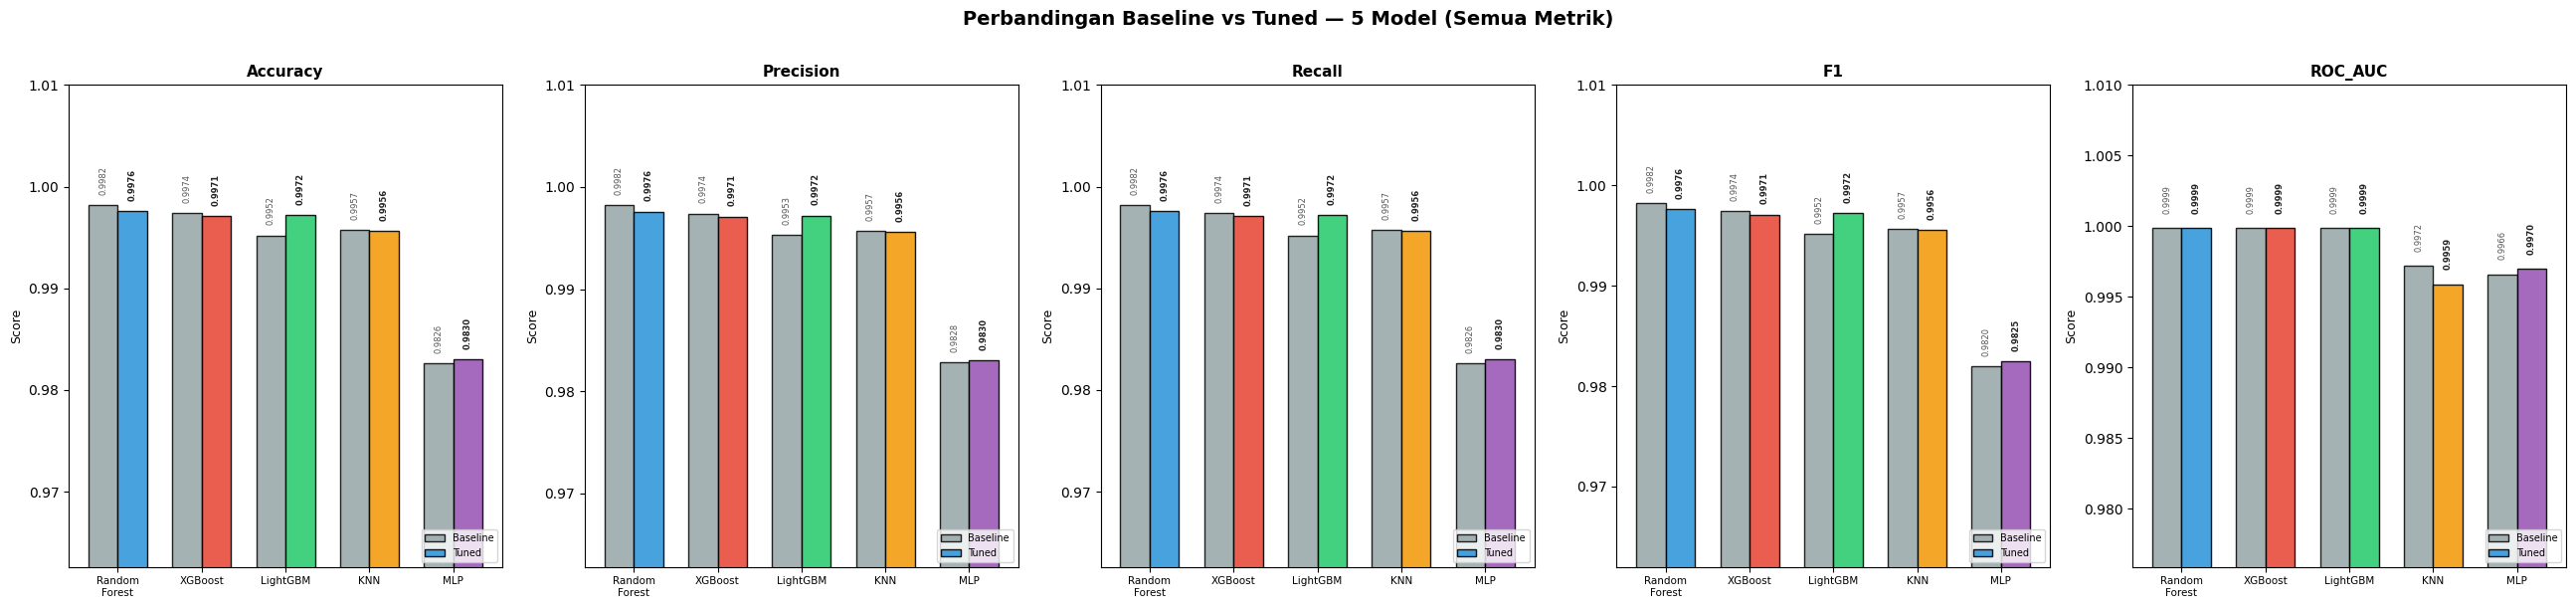

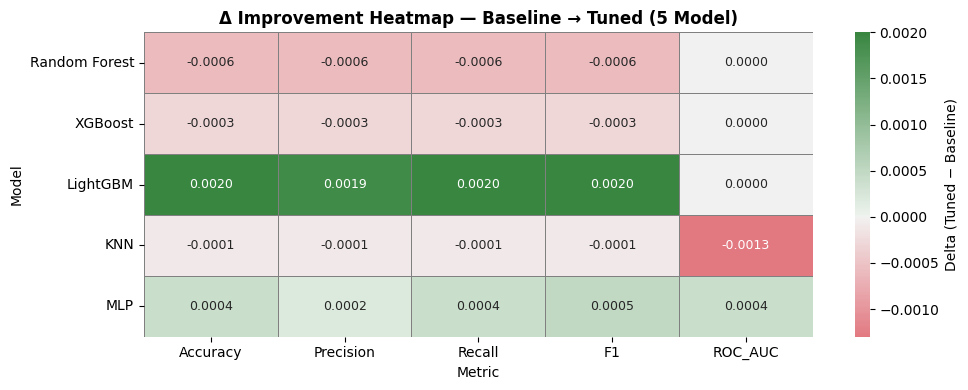

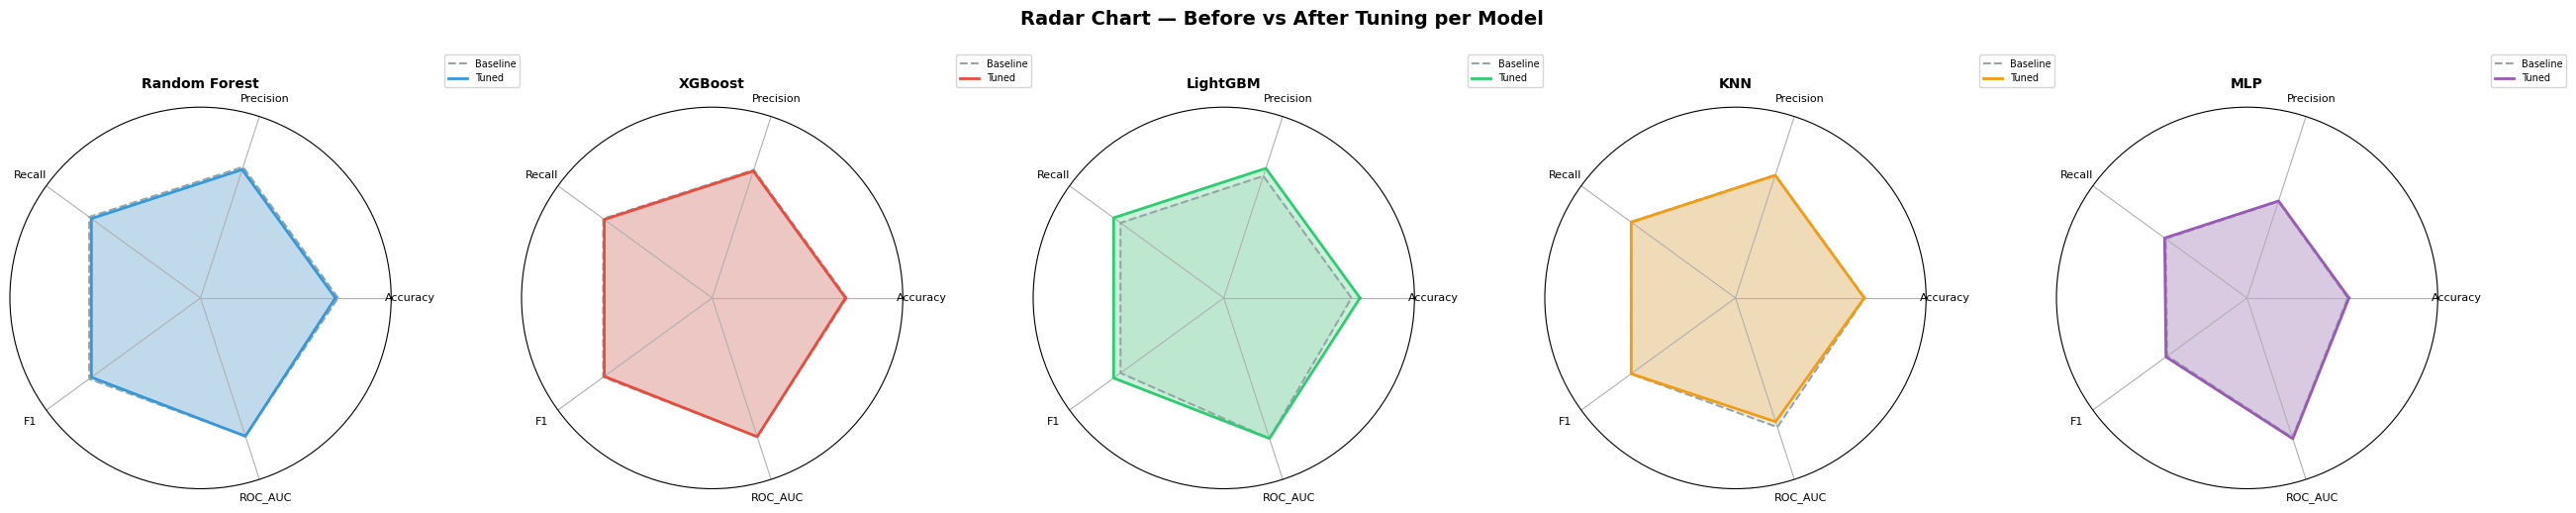


RINGKASAN DELTA IMPROVEMENT — BASELINE → TUNED (5 MODEL)
  Model                Accuracy   Precision      Recall          F1     ROC_AUC
  ----------------------------------------------------------------------------
  Random Forest        -0.0006    -0.0006    -0.0006    -0.0006+     0.0000
  XGBoost              -0.0003    -0.0003    -0.0003    -0.0003+     0.0000
  LightGBM         +     0.0020+     0.0019+     0.0020+     0.0020+     0.0000
  KNN                  -0.0001    -0.0001    -0.0001    -0.0001    -0.0013
  MLP              +     0.0004+     0.0002+     0.0004+     0.0005+     0.0004
Positif (+) = Tuned lebih baik | Negatif (-) = Baseline lebih baik


In [ ]:
# ================================================================
# VISUALISASI BEFORE vs AFTER TUNING — 5 MODEL
# ================================================================

import numpy as np

tuned_all = {
    'Random Forest': rf_res,
    'XGBoost'      : xgb_res,
    'LightGBM'     : lgb_res,
    'KNN'          : knn_res,
    'MLP'          : mlp_res,
}

model_names  = list(tuned_all.keys())
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
colors_model = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# ── 1. Grouped Bar Chart: Baseline vs Tuned per Metric ──────────────
fig, axes = plt.subplots(1, 5, figsize=(26, 6))
bar_width = 0.35
x = np.arange(len(model_names))

for ax, metric in zip(axes, metrics):
    vals_base  = [float(baseline_results[m][metric]) for m in model_names]
    vals_tuned = [float(tuned_all[m][metric])        for m in model_names]

    bars_b = ax.bar(x - bar_width/2, vals_base,  bar_width,
                    label='Baseline', color='#95a5a6', edgecolor='black', alpha=0.85)
    bars_t = ax.bar(x + bar_width/2, vals_tuned, bar_width,
                    label='Tuned',    color=colors_model, edgecolor='black', alpha=0.9)

    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7.5)

    all_vals = vals_base + vals_tuned
    ax.set_ylim(max(0, min(all_vals) - 0.02), min(1.01, max(all_vals) + 0.025))
    ax.set_ylabel('Score', fontsize=9)

    for bar, val in zip(bars_b, vals_base):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=6, rotation=90, color='#555')
    for bar, val in zip(bars_t, vals_tuned):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=6, rotation=90,
                color='#222', fontweight='bold')

    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Perbandingan Baseline vs Tuned — 5 Model (Semua Metrik)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('modelling_08_before_after_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Delta Improvement Heatmap ────────────────────────────────────
delta_data = {
    metric: [float(tuned_all[m][metric]) - float(baseline_results[m][metric]) for m in model_names]
    for metric in metrics
}
delta_df = pd.DataFrame(delta_data, index=model_names)

fig, ax = plt.subplots(figsize=(10, 4))
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(delta_df, annot=True, fmt='.4f', cmap=cmap, center=0,
            linewidths=0.5, linecolor='grey',
            cbar_kws={'label': 'Delta (Tuned − Baseline)'},
            ax=ax, annot_kws={'fontsize': 9})
ax.set_title('Δ Improvement Heatmap — Baseline → Tuned (5 Model)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Metric', fontsize=10)
ax.set_ylabel('Model', fontsize=10)
plt.tight_layout()
plt.savefig('modelling_09_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Radar Chart per Model ─────────────────────────────────────────
N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, axes = plt.subplots(1, 5, figsize=(26, 5), subplot_kw=dict(projection='polar'))

for ax, model_name, color in zip(axes, model_names, colors_model):
    vals_b = [float(baseline_results[model_name][m]) for m in metrics] + \
             [float(baseline_results[model_name][metrics[0]])]
    vals_t = [float(tuned_all[model_name][m]) for m in metrics] + \
             [float(tuned_all[model_name][metrics[0]])]

    ax.plot(angles, vals_b, linewidth=1.5, linestyle='--', color='#95a5a6', label='Baseline')
    ax.fill(angles, vals_b, alpha=0.15, color='#95a5a6')
    ax.plot(angles, vals_t, linewidth=2,   linestyle='-',  color=color,     label='Tuned')
    ax.fill(angles, vals_t, alpha=0.25, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=8)
    ax.set_ylim(max(0.0, min(vals_b + vals_t) - 0.03), 1.01)
    ax.set_yticks([])
    ax.set_title(model_name, fontweight='bold', fontsize=10, pad=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=7)

plt.suptitle('Radar Chart — Before vs After Tuning per Model',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('modelling_10_radar_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Tabel Ringkasan Delta ─────────────────────────────────────────
print("\n" + "="*70)
print("RINGKASAN DELTA IMPROVEMENT — BASELINE → TUNED (5 MODEL)")
print("="*70)
print(f"  {'Model':<16} " + "".join(f"{m:>12}" for m in metrics))
print("  " + "-"*76)
for model_name in model_names:
    row = f"  {model_name:<16} "
    for metric in metrics:
        d = float(tuned_all[model_name][metric]) - float(baseline_results[model_name][metric])
        row += f"{'+' if d >= 0 else ''}{d:>11.4f}"
    print(row)
print("="*70)
print("Positif (+) = Tuned lebih baik | Negatif (-) = Baseline lebih baik")

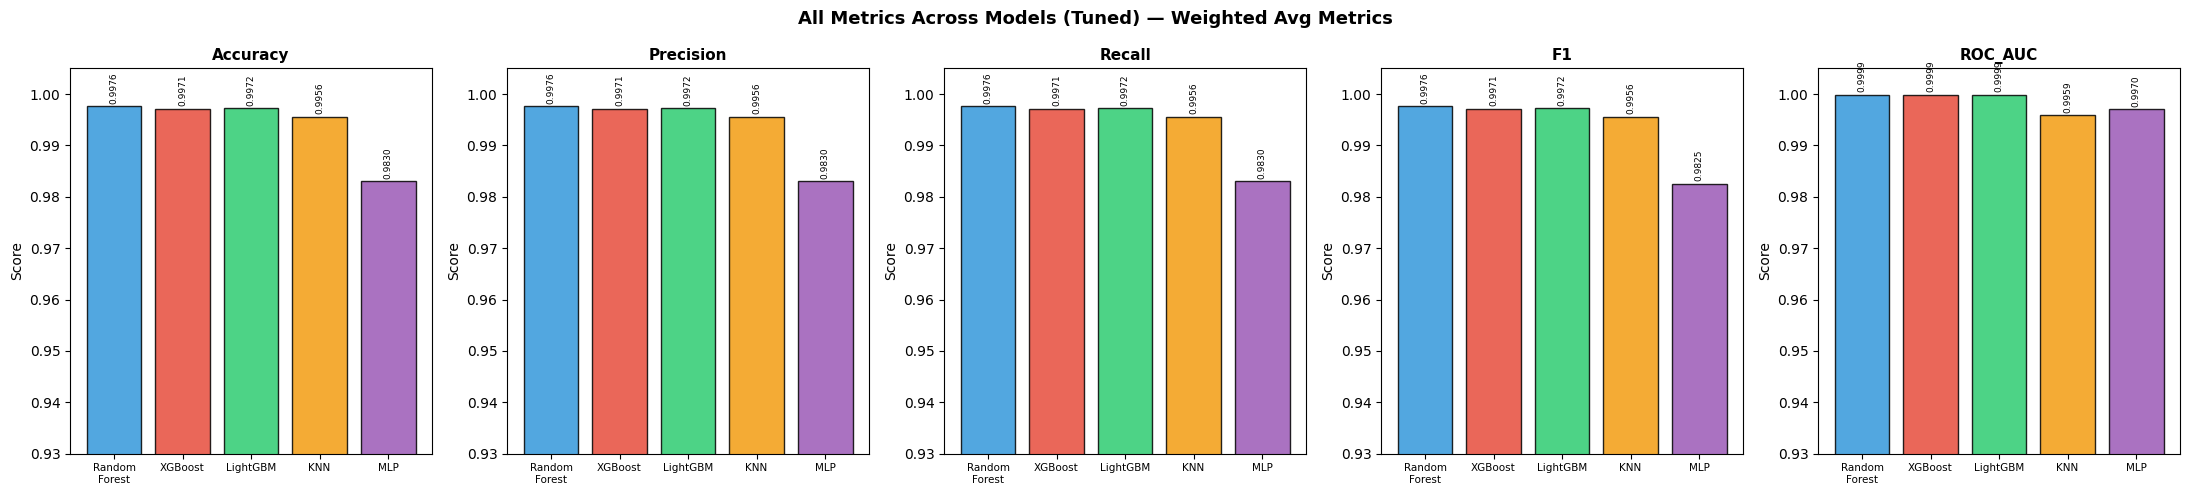

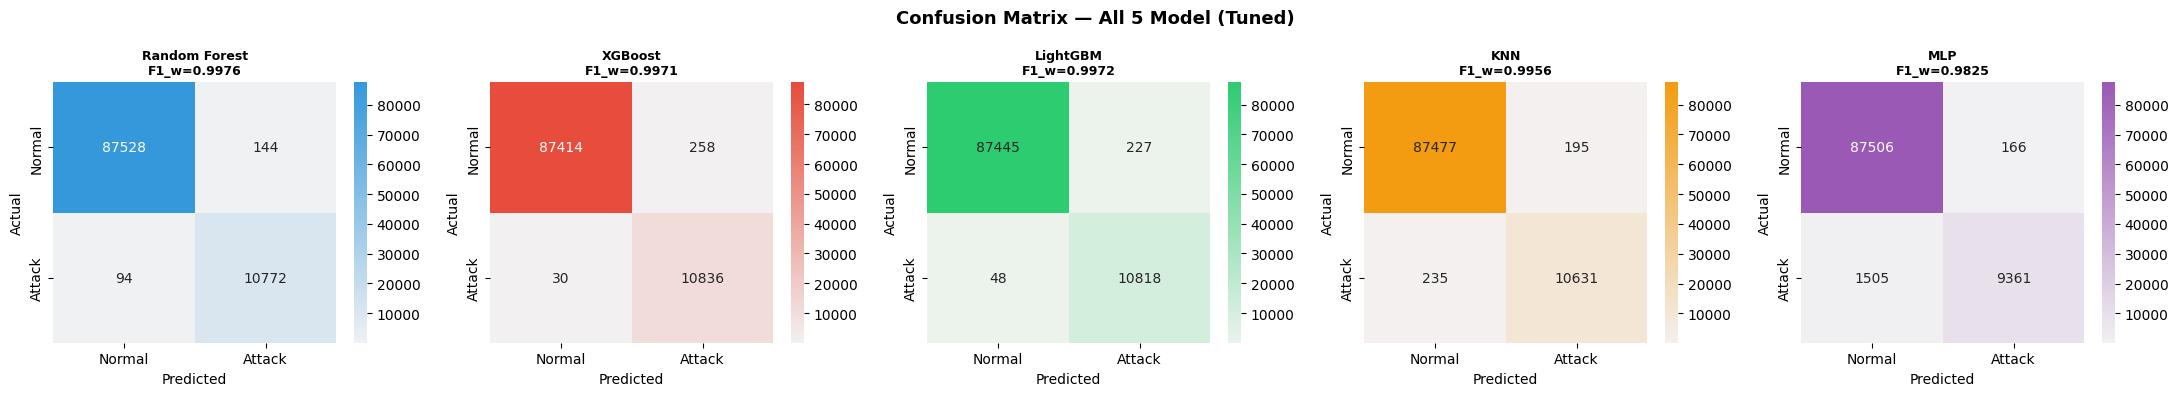

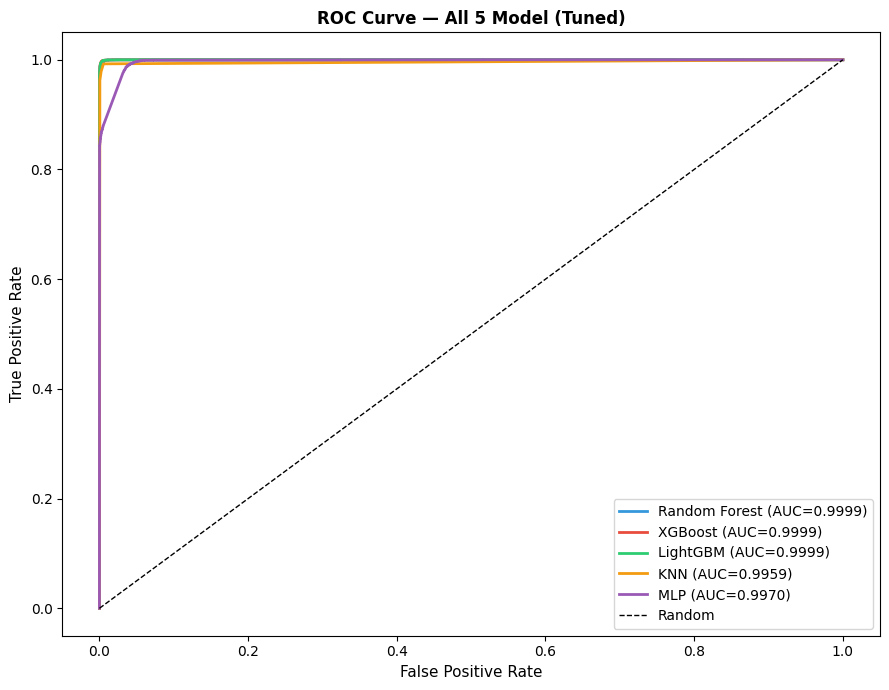


Model terbaik disimpan: model_best_deployment.joblib
→ Random Forest dengan F1_weighted=0.9976


In [ ]:
# Visualisasi final
model_names = list(all_results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, metric in enumerate(metrics):
    vals = [float(all_results[m][metric]) for m in model_names]
    bars = axes[i].bar(range(len(model_names)), vals,
                        color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold', fontsize=11)
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7.5)
    axes[i].set_ylim(0.93, 1.005)
    axes[i].set_ylabel('Score')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + 0.0005, f'{val:.4f}',
                     ha='center', va='bottom', fontsize=6.5, rotation=90)
plt.suptitle('All Metrics Across Models (Tuned) — Weighted Avg Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelling_05_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix semua 5 model
all_preds = {
    'Random Forest': (y_pred_rf,  y_prob_rf,  '#3498db'),
    'XGBoost'      : (y_pred_xgb, y_prob_xgb, '#e74c3c'),
    'LightGBM'     : (y_pred_lgb, y_prob_lgb, '#2ecc71'),
    'KNN'          : (y_pred_knn, y_prob_knn, '#f39c12'),
    'MLP'          : (y_pred_mlp, y_prob_mlp, '#9b59b6'),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, (y_pred, y_prob, color)) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    f1 = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'{name}\nF1_w={f1:.4f}', fontweight='bold', fontsize=9)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix — All 5 Model (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelling_06_all_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve semua model
fig, ax = plt.subplots(figsize=(9, 7))
for name, (y_pred, y_prob, color) in all_preds.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — All 5 Model (Tuned)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('modelling_07_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan model terbaik
best_model_obj = {
    'Random Forest': rf_best,
    'XGBoost'      : xgb_best,
    'LightGBM'     : lgb_best,
    'KNN'          : knn_final,
    'MLP'          : mlp_final,
}[best_model_name]
joblib.dump(best_model_obj, 'model_best_deployment.joblib')
print(f"\nModel terbaik disimpan: model_best_deployment.joblib")
print(f"→ {best_model_name} dengan F1_weighted={float(results_df.loc[best_model_name,'F1']):.4f}")


# Streamlit Deployment App

In [ ]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import io

# ──────────────────────────────────────────────
# PAGE CONFIG
# ──────────────────────────────────────────────
st.set_page_config(
    page_title="CUPID NIDS | SOC Dashboard",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ──────────────────────────────────────────────
# GLOBAL CSS
# ──────────────────────────────────────────────
st.markdown("""
<style>
/* base */
.main { background-color: #0B0F19; }
section[data-testid="stSidebar"] { background-color: #111827; }

/* typography */
h1, h2, h3 { color: #38BDF8; letter-spacing: .03em; }
p, label, .stRadio label { color: #CBD5E1; }

/* metric cards */
div[data-testid="metric-container"] {
    background: linear-gradient(135deg, #1E293B 0%, #0F172A 100%);
    border: 1px solid #334155;
    border-left: 4px solid #38BDF8;
    border-radius: 12px;
    padding: 18px 20px;
}
div[data-testid="metric-container"] label { color: #94A3B8 !important; font-size:.8rem; text-transform:uppercase; letter-spacing:.08em; }
div[data-testid="metric-container"] div[data-testid="stMetricValue"] { color: #F8FAFC !important; font-size:1.7rem; font-weight:700; }
div[data-testid="metric-container"] div[data-testid="stMetricDelta"] { color: #4ADE80 !important; }

/* buttons */
div.stButton > button {
    background: linear-gradient(90deg,#0EA5E9,#6366F1);
    color: #fff; border: none; border-radius: 8px;
    padding: 10px 28px; font-weight: 600; letter-spacing:.04em;
    transition: opacity .2s;
}
div.stButton > button:hover { opacity: .85; }

/* selectbox / slider labels */
.stSelectbox label, .stSlider label { color: #94A3B8 !important; }

/* tab strip */
button[data-baseweb="tab"] { color: #94A3B8 !important; font-weight:600; }
button[data-baseweb="tab"][aria-selected="true"] { color:#38BDF8 !important; border-bottom-color:#38BDF8 !important; }

/* status pill */
.pill-ok  { display:inline-block; background:#064E3B; color:#4ADE80; border:1px solid #4ADE80; border-radius:999px; padding:3px 14px; font-size:.8rem; font-weight:700; }
.pill-bad { display:inline-block; background:#450A0A; color:#F87171; border:1px solid #F87171; border-radius:999px; padding:3px 14px; font-size:.8rem; font-weight:700; }

/* divider */
hr { border-color: #1E293B; }

/* plotly charts transparent background */
.js-plotly-plot .plotly { background: transparent !important; }
</style>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────────
# HELPERS / THEME
# ──────────────────────────────────────────────
PLOTLY_LAYOUT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(15,23,42,0.6)",
    font=dict(color="#CBD5E1", family="Inter, sans-serif"),
    xaxis=dict(gridcolor="#1E293B", zerolinecolor="#1E293B"),
    yaxis=dict(gridcolor="#1E293B", zerolinecolor="#1E293B"),
    margin=dict(t=50, b=40, l=40, r=20),
)
PALETTE = ["#38BDF8","#818CF8","#34D399","#FB923C","#F472B6"]

def styled_chart(fig, height=420):
    fig.update_layout(**PLOTLY_LAYOUT, height=height)
    st.plotly_chart(fig, use_container_width=True)

# ──────────────────────────────────────────────
# DATA / ARTIFACT LOADERS
# ──────────────────────────────────────────────
@st.cache_resource(show_spinner="Loading models…")
def load_artifacts():
    models = {
        "Random Forest": joblib.load("model_rf_tuned.joblib"),
        "XGBoost":       joblib.load("model_xgb_tuned.joblib"),
        "LightGBM":      joblib.load("model_lgb_tuned.joblib"),
        "KNN":           joblib.load("model_knn_tuned.joblib"),
        "MLP":           joblib.load("model_mlp_tuned.joblib"),
    }
    return models, joblib.load("scaler_final.joblib"), joblib.load("feature_names.joblib")

@st.cache_data(show_spinner="Loading test data…")
def load_test_data():
    df = pd.read_parquet("CUPID_final_test_scaled.parquet")
    return df.drop(columns=["Label"]), df["Label"]

models, scaler, feature_names = load_artifacts()
X_test, y_test = load_test_data()

# Pre-compute all model predictions once
@st.cache_data(show_spinner="Running model predictions…")
def compute_all_preds():
    out = {}
    for name, m in models.items():
        yp   = m.predict(X_test)
        prob = m.predict_proba(X_test)[:, 1]
        out[name] = dict(
            pred=yp, prob=prob,
            acc  = accuracy_score(y_test, yp),
            f1   = f1_score(y_test, yp, average="weighted"),
            prec = precision_score(y_test, yp, average="weighted", zero_division=0),
            rec  = recall_score(y_test, yp, average="weighted", zero_division=0),
            auc  = roc_auc_score(y_test, prob),
        )
    return out

all_preds = compute_all_preds()

# ──────────────────────────────────────────────
# SIDEBAR NAVIGATION
# ──────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🛡️ CUPID NIDS")
    st.markdown("<p style='color:#64748B;font-size:.8rem;'>Network Intrusion Detection System</p>", unsafe_allow_html=True)
    st.markdown("---")
    menu = st.radio("Navigation", [
        "📊 Executive Summary",
        "🔬 Model Interrogation",
        "📈 Threat Forecasting",
        "🔍 Deep EDA",
        "⚡ Real-Time Engine",
        "📂 Batch Inspection",
    ])
    st.markdown("---")
    st.markdown(f"<p style='color:#475569;font-size:.75rem;'>Test samples: <b style='color:#94A3B8'>{len(X_test):,}</b><br>Features: <b style='color:#94A3B8'>{len(feature_names)}</b><br>Models: <b style='color:#94A3B8'>{len(models)}</b></p>", unsafe_allow_html=True)


# ══════════════════════════════════════════════
# 1. EXECUTIVE SUMMARY
# ══════════════════════════════════════════════
if menu == "📊 Executive Summary":
    st.title("📊 CUPID NIDS — Model Evaluation Summary")
    st.markdown("""
    <div style='background:#1E293B;border-left:4px solid #F59E0B;border-radius:8px;padding:12px 16px;margin-bottom:16px;'>
    <span style='color:#F59E0B;font-weight:700;font-size:.85rem;'>⚠️ OFFLINE EVALUATION MODE</span><br>
    <span style='color:#94A3B8;font-size:.85rem;'>All metrics below are derived from the <b style='color:#CBD5E1'>static CUPID test set</b> (20,000 samples).
    This is not a real-time monitoring system — no live network traffic is being analysed.</span>
    </div>
    """, unsafe_allow_html=True)

    threat_n   = int(y_test.sum())
    benign_n   = int(len(y_test) - threat_n)
    best_model = max(all_preds, key=lambda m: all_preds[m]["f1"])
    best_f1    = all_preds[best_model]["f1"]

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Test Set Size",         f"{len(X_test):,} samples")
    c2.metric("Attack Samples (GT)",   f"{threat_n:,}", delta=f"{threat_n/len(y_test)*100:.1f}% of test set")
    c3.metric("Benign Samples (GT)",   f"{benign_n:,}")
    c4.metric("Best F1 Score",         f"{best_f1:.4f}", delta=f"by {best_model}")
    c5.metric("Data Source",           "Offline Test Set")

    st.markdown("---")
    col_a, col_b = st.columns([1, 2])

    with col_a:
        st.markdown("#### Traffic Composition")
        fig_pie = go.Figure(go.Pie(
            labels=["Benign", "Threat"],
            values=[benign_n, threat_n],
            hole=.55,
            marker=dict(colors=["#34D399","#F87171"]),
            textfont_size=13,
        ))
        fig_pie.add_annotation(text=f"<b>{threat_n/len(y_test)*100:.1f}%</b><br>Threat", x=.5, y=.5,
                               font=dict(size=16, color="#F8FAFC"), showarrow=False)
        styled_chart(fig_pie, height=320)

    with col_b:
        st.markdown("#### All-Model Performance at a Glance")
        rows = []
        for name, p in all_preds.items():
            rows.append({"Model": name, "Accuracy": p["acc"], "F1": p["f1"],
                         "Precision": p["prec"], "Recall": p["rec"], "ROC-AUC": p["auc"]})
        df_perf = pd.DataFrame(rows).set_index("Model")

        fig_bar = go.Figure()
        for i, col in enumerate(["Accuracy","F1","Precision","Recall","ROC-AUC"]):
            fig_bar.add_trace(go.Bar(name=col, x=df_perf.index, y=df_perf[col],
                                     marker_color=PALETTE[i]))
        fig_bar.update_layout(barmode="group", **PLOTLY_LAYOUT, height=320,
                              legend=dict(orientation="h", y=-0.2))
        st.plotly_chart(fig_bar, use_container_width=True)

    st.markdown("---")
    st.markdown("#### Threat Distribution over Test Window")
    chunk = st.slider("Chunk size (samples per bin)", 100, 2000, 500, 100)
    counts_raw = [int(y_test.iloc[i*chunk:(i+1)*chunk].sum()) for i in range(len(y_test)//chunk)]
    fig_line = px.area(x=list(range(len(counts_raw))), y=counts_raw,
                       labels={"x":"Window Index","y":"Threat Count"},
                       color_discrete_sequence=["#38BDF8"])
    fig_line.update_traces(fill="tozeroy", line_color="#38BDF8")
    styled_chart(fig_line, 280)


# ══════════════════════════════════════════════
# 2. MODEL INTERROGATION
# ══════════════════════════════════════════════
elif menu == "🔬 Model Interrogation":
    st.title("Model Performance Analysis")

    tab1, tab2, tab3 = st.tabs(["Single Model Deep-Dive", "ROC Curve Overlay", "Head-to-Head Compare"])

    # ── TAB 1: Single model ──────────────────────
    with tab1:
        selected_model = st.selectbox("Select Model", list(models.keys()), key="mi_single")
        p = all_preds[selected_model]

        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Accuracy",  f"{p['acc']:.4f}")
        c2.metric("F1 (W)",    f"{p['f1']:.4f}")
        c3.metric("Precision", f"{p['prec']:.4f}")
        c4.metric("ROC-AUC",   f"{p['auc']:.4f}")

        col_cm, col_dist = st.columns([1,1])

        with col_cm:
            st.markdown("#### Confusion Matrix")
            cm = confusion_matrix(y_test, p["pred"])
            fig_cm = px.imshow(
                cm, text_auto=True, aspect="auto",
                color_continuous_scale="Blues",
                labels=dict(x="Predicted", y="Actual"),
                x=["Benign","Attack"], y=["Benign","Attack"],
            )
            fig_cm.update_traces(textfont_size=18)
            styled_chart(fig_cm, 360)

        with col_dist:
            st.markdown("#### Prediction Probability Distribution")
            fig_hist = go.Figure()
            for label, color, name in [(0,"#34D399","Benign"),(1,"#F87171","Attack")]:
                mask = (y_test == label)
                fig_hist.add_trace(go.Histogram(
                    x=p["prob"][mask], name=name, nbinsx=50,
                    marker_color=color, opacity=.75,
                ))
            fig_hist.update_layout(**PLOTLY_LAYOUT, height=360, barmode="overlay",
                                   xaxis_title="Predicted Probability", yaxis_title="Count",
                                   legend=dict(orientation="h"))
            st.plotly_chart(fig_hist, use_container_width=True)

    # ── TAB 2: ROC overlay ──────────────────────
    with tab2:
        st.markdown("#### ROC Curve — All Models")
        compare_models = st.multiselect("Models to display", list(models.keys()),
                                        default=list(models.keys()), key="mi_roc")
        fig_roc = go.Figure()
        fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines",
                                     line=dict(dash="dash", color="#475569"), name="Random"))
        for i, name in enumerate(compare_models):
            fpr, tpr, _ = roc_curve(y_test, all_preds[name]["prob"])
            auc = all_preds[name]["auc"]
            fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines",
                                         name=f"{name} (AUC={auc:.3f})",
                                         line=dict(color=PALETTE[i % len(PALETTE)], width=2)))
        fig_roc.update_layout(**PLOTLY_LAYOUT, height=480,
                              xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
        st.plotly_chart(fig_roc, use_container_width=True)

    # ── TAB 3: Head-to-head ─────────────────────
    with tab3:
        st.markdown("#### Side-by-Side Metric Radar")
        h2h_models = st.multiselect("Select models to compare", list(models.keys()),
                                    default=list(models.keys())[:3], key="mi_h2h")
        metrics_keys   = ["acc","f1","prec","rec","auc"]
        metrics_labels = ["Accuracy","F1","Precision","Recall","ROC-AUC"]

        def hex_to_rgba(hex_color, alpha=0.15):
            h = hex_color.lstrip("#")
            r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
            return f"rgba({r},{g},{b},{alpha})"

        fig_radar = go.Figure()
        for i, name in enumerate(h2h_models):
            vals = [all_preds[name][k] for k in metrics_keys]
            color = PALETTE[i % len(PALETTE)]
            fig_radar.add_trace(go.Scatterpolar(
                r=vals + [vals[0]], theta=metrics_labels + [metrics_labels[0]],
                fill="toself", name=name, opacity=.7,
                line=dict(color=color),
                fillcolor=hex_to_rgba(color, 0.15),
            ))
        fig_radar.update_layout(**PLOTLY_LAYOUT, height=460,
                                polar=dict(bgcolor="rgba(15,23,42,0.6)",
                                           radialaxis=dict(range=[0,1], gridcolor="#1E293B"),
                                           angularaxis=dict(gridcolor="#1E293B")),
                                legend=dict(orientation="h"))
        st.plotly_chart(fig_radar, use_container_width=True)

        # Numeric comparison table
        rows = {m: {l: all_preds[m][k] for k,l in zip(metrics_keys, metrics_labels)} for m in h2h_models}
        df_h2h = pd.DataFrame(rows).T
        st.dataframe(df_h2h.style.format("{:.4f}"), use_container_width=True)


# ══════════════════════════════════════════════
# 3. THREAT FORECASTING
# ══════════════════════════════════════════════
elif menu == "📈 Threat Forecasting":
    st.title("Threat Forecasting Analytics")
    st.markdown("<p style='color:#64748B'>Fit Exponential Smoothing on historic threat windows and project forward.</p>", unsafe_allow_html=True)

    col_ctrl, col_main = st.columns([1, 3])

    with col_ctrl:
        chunk     = st.slider("Window size (samples)", 100, 2000, 500, 100)
        horizon   = st.slider("Forecast horizon (windows)", 5, 100, 24, 1)
        trend_opt = st.selectbox("Trend component", ["add", "mul", None])
        seas_opt  = st.selectbox("Seasonal component", [None, "add", "mul"])
        seas_per  = st.slider("Seasonal period", 2, 24, 6) if seas_opt else 2
        run_btn   = st.button("Run Forecast", type="primary")

    with col_main:
        counts_raw = [int(y_test.iloc[i*chunk:(i+1)*chunk].sum())
                      for i in range(len(y_test)//chunk)]

        if run_btn or "forecast_result" not in st.session_state:
            try:
                kwargs = dict(trend=trend_opt)
                if seas_opt:
                    kwargs["seasonal"]         = seas_opt
                    kwargs["seasonal_periods"] = seas_per
                model_es   = ExponentialSmoothing(counts_raw, **kwargs).fit()
                fc         = model_es.forecast(horizon)
                fitted_val = model_es.fittedvalues
                st.session_state["forecast_result"] = (counts_raw, fc, fitted_val)
            except Exception as e:
                st.error(f"Fitting failed: {e}")
                st.stop()

        counts_raw, fc, fitted_val = st.session_state["forecast_result"]
        hist_idx = list(range(len(counts_raw)))
        fc_idx   = list(range(len(counts_raw), len(counts_raw) + horizon))

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=hist_idx, y=counts_raw, name="Observed",
                                 line=dict(color="#38BDF8", width=2)))
        fig.add_trace(go.Scatter(x=hist_idx, y=fitted_val, name="ES Fitted",
                                 line=dict(color="#818CF8", width=1.5, dash="dot")))
        fig.add_trace(go.Scatter(x=fc_idx, y=fc, name="Forecast",
                                 line=dict(color="#FB923C", width=2.5)))
        # Confidence band (±1 std of residuals)
        resid_std = np.std(np.array(counts_raw) - np.array(fitted_val))
        fig.add_trace(go.Scatter(
            x=fc_idx + fc_idx[::-1],
            y=list(fc + resid_std) + list((fc - resid_std)[::-1]),
            fill="toself", fillcolor="rgba(251,146,60,.15)",
            line=dict(color="rgba(0,0,0,0)"), name="±1 StdDev Band",
        ))
        fig.update_layout(**PLOTLY_LAYOUT, height=460,
                          xaxis_title="Window Index", yaxis_title="Threat Count",
                          legend=dict(orientation="h", y=-0.15))
        st.plotly_chart(fig, use_container_width=True)

        # Download forecast
        fc_arr     = np.array(fc).flatten()
        fc_idx_arr = np.array(fc_idx)
        assert len(fc_arr) == len(fc_idx_arr), f"Length mismatch: fc={len(fc_arr)} idx={len(fc_idx_arr)}"
        fc_df = pd.DataFrame({"Window": fc_idx_arr, "Forecast": fc_arr,
                               "Lower": fc_arr - resid_std,
                               "Upper": fc_arr + resid_std})
        st.download_button("⬇ Download Forecast CSV", fc_df.to_csv(index=False).encode(),
                           "forecast.csv", "text/csv")


# ══════════════════════════════════════════════
# 4. DEEP EDA
# ══════════════════════════════════════════════
elif menu == "🔍 Deep EDA":
    st.title("Exploratory Data Analysis")

    df_eda = pd.concat([X_test.reset_index(drop=True),
                        y_test.reset_index(drop=True).rename("Label")], axis=1)
    df_eda["Label_str"] = df_eda["Label"].map({0: "Benign", 1: "Attack"})

    tab1, tab2, tab3 = st.tabs(["Distribution Explorer", "Correlation Heatmap", "Scatter Matrix"])

    # ── TAB 1 ────────────────────────────────────
    with tab1:
        col_ctrl, col_chart = st.columns([1, 3])
        with col_ctrl:
            feat      = st.selectbox("Feature", feature_names, key="eda_feat")
            plot_type = st.radio("Plot type", ["Violin","Box","Histogram"])
            sample_n  = st.slider("Subsample (rows)", 500, min(10000, len(df_eda)), 3000, 500)

        df_s = df_eda.sample(sample_n, random_state=42)
        with col_chart:
            if plot_type == "Violin":
                fig = px.violin(df_s, y=feat, x="Label_str", color="Label_str",
                                box=True, points="outliers",
                                color_discrete_map={"Benign":"#34D399","Attack":"#F87171"})
            elif plot_type == "Box":
                fig = px.box(df_s, y=feat, x="Label_str", color="Label_str",
                             color_discrete_map={"Benign":"#34D399","Attack":"#F87171"})
            else:
                fig = px.histogram(df_s, x=feat, color="Label_str", nbins=60, barmode="overlay",
                                   opacity=.7,
                                   color_discrete_map={"Benign":"#34D399","Attack":"#F87171"})
            fig.update_layout(showlegend=True, **PLOTLY_LAYOUT, height=420)
            st.plotly_chart(fig, use_container_width=True)

        # Quick stats table
        st.markdown("#### Descriptive Statistics by Class")
        st.dataframe(df_eda.groupby("Label_str")[feat].describe().T.style.format("{:.4f}"),
                     use_container_width=True)

    # ── TAB 2: Correlation ───────────────────────
    with tab2:
        c_opt1, c_opt2 = st.columns([2, 1])
        with c_opt1:
            feat_mode = st.radio("Feature selection", ["All features", "Top N by variance"],
                                 horizontal=True)
        with c_opt2:
            show_full = st.checkbox("Show full matrix (instead of lower triangle)", value=False)

        if feat_mode == "All features":
            top_feats = feature_names
        else:
            top_n = st.slider("Top N features by variance", 5, min(40, len(feature_names)), 15)
            top_feats = X_test.var().nlargest(top_n).index.tolist()

        corr = df_eda[top_feats].corr()

        # Lower triangle mask
        if not show_full:
            mask = np.tril(np.ones(corr.shape, dtype=bool))
            corr_display = corr.where(mask)
        else:
            corr_display = corr

        n_feats  = len(top_feats)
        chart_h  = max(520, n_feats * 22)

        fig_corr = px.imshow(
            corr_display,
            color_continuous_scale="RdBu_r",
            zmin=-1, zmax=1,
            aspect="auto",
            title=f"Pearson Correlation — {len(top_feats)} Features {'(Lower Triangle)' if not show_full else '(Full Matrix)'}",
            text_auto=".2f" if n_feats <= 20 else False,
        )
        fig_corr.update_traces(textfont_size=9)
        fig_corr.update_layout(
            coloraxis_colorbar=dict(title="r", thickness=14, len=0.8),
            xaxis=dict(tickangle=-45, tickfont_size=10),
            yaxis=dict(tickfont_size=10),
        )
        styled_chart(fig_corr, height=chart_h)

    # ── TAB 3: Scatter matrix ────────────────────
    with tab3:
        scatter_feats = st.multiselect("Features for scatter matrix", feature_names,
                                       default=feature_names[:4])
        if len(scatter_feats) < 2:
            st.info("Select at least 2 features.")
        else:
            sample_sc = df_eda.sample(min(2000, len(df_eda)), random_state=1)
            fig_sp = px.scatter_matrix(
                sample_sc, dimensions=scatter_feats, color="Label_str",
                color_discrete_map={"Benign":"#34D399","Attack":"#F87171"},
                opacity=.5,
            )
            fig_sp.update_traces(marker=dict(size=3))
            styled_chart(fig_sp, height=600)


# ══════════════════════════════════════════════
# 5. REAL-TIME ENGINE
# ══════════════════════════════════════════════
elif menu == "⚡ Real-Time Engine":
    st.title("Real-Time Inference Engine")

    col_left, col_right = st.columns([1, 1])

    with col_left:
        model_name = st.selectbox("Model", list(models.keys()), key="rt_model")

        btn_cols = st.columns(2)
        if btn_cols[0].button("🎲 Random Sample (Benign)"):
            idx = np.random.choice(np.where(y_test == 0)[0])
            st.session_state["rt_sample"] = X_test.iloc[idx].to_dict()
            st.session_state.pop("rt_result", None)
        if btn_cols[1].button("🎯 Random Sample (Attack)"):
            idx = np.random.choice(np.where(y_test == 1)[0])
            st.session_state["rt_sample"] = X_test.iloc[idx].to_dict()
            st.session_state.pop("rt_result", None)

        # Initialise default sample on first load
        if "rt_sample" not in st.session_state:
            st.session_state["rt_sample"] = {f: float(X_test[f].mean()) for f in feature_names}

        sample = st.session_state["rt_sample"]
        vals = {}
        for f in feature_names:
            fmin = float(X_test[f].min())
            fmax = float(X_test[f].max())
            fval = float(sample.get(f, X_test[f].mean()))
            fval = max(fmin, min(fmax, fval))   # clamp to valid range
            vals[f] = st.number_input(
                f, min_value=fmin, max_value=fmax,
                value=fval, step=(fmax - fmin) / 100 or 0.001,
                format="%.4f",
            )

    with col_right:
        if st.button("⚡ Execute Prediction", type="primary", key="rt_predict"):
            input_df = pd.DataFrame([vals])[feature_names]
            # X_test is already scaled (CUPID_final_test_scaled.parquet),
            # so values from number_input are in scaled space — no transform needed.
            prob      = models[model_name].predict_proba(input_df.values)[0][1]
            is_attack = prob > 0.5
            st.session_state["rt_result"] = (prob, is_attack, input_df)

        if "rt_result" in st.session_state:
            prob, is_attack, input_df = st.session_state["rt_result"]

            # Status badge
            if is_attack:
                st.markdown('<span class="pill-bad">🚨 MALICIOUS ATTACK DETECTED</span>', unsafe_allow_html=True)
            else:
                st.markdown('<span class="pill-ok">✅ TRAFFIC BENIGN</span>', unsafe_allow_html=True)

            st.markdown(f"<br>**Detection Confidence: {prob*100:.2f}%**", unsafe_allow_html=True)

            # Gauge
            gauge_color = "#F87171" if is_attack else "#34D399"
            fig_gauge = go.Figure(go.Indicator(
                mode="gauge+number+delta",
                value=prob * 100,
                delta={"reference": 50, "suffix":"%"},
                number={"suffix":"%", "font":{"color": gauge_color, "size":42}},
                gauge={
                    "axis": {"range": [0, 100], "tickcolor": "#475569"},
                    "bar":  {"color": gauge_color, "thickness": .25},
                    "bgcolor": "#1E293B",
                    "steps": [
                        {"range":[0,50],   "color":"#064E3B"},
                        {"range":[50,100], "color":"#450A0A"},
                    ],
                    "threshold": {"line":{"color":"white","width":3}, "thickness":.75, "value":50},
                },
            ))
            fig_gauge.update_layout(**PLOTLY_LAYOUT, height=300)
            st.plotly_chart(fig_gauge, use_container_width=True)

            # Feature impact bar — top 15 by absolute deviation from mean
            st.markdown("#### Feature Deviation from Mean")
            means    = X_test[feature_names].mean()
            row_val  = pd.Series(vals)[feature_names]
            deviations = ((row_val - means) / (X_test[feature_names].std() + 1e-9))
            top15  = deviations.abs().nlargest(15).index
            dev15  = deviations[top15]
            colors = ["#F87171" if v > 0 else "#34D399" for v in dev15.values]
            fig_bar = go.Figure(go.Bar(x=dev15.values, y=top15, orientation="h",
                                       marker_color=colors))
            bar_layout = {**PLOTLY_LAYOUT, "height": 320, "xaxis_title": "Z-score deviation"}
            bar_layout["yaxis"] = dict(autorange="reversed", gridcolor="#1E293B")
            fig_bar.update_layout(**bar_layout)
            st.plotly_chart(fig_bar, use_container_width=True)


# ══════════════════════════════════════════════
# 6. BATCH INSPECTION
# ══════════════════════════════════════════════
elif menu == "📂 Batch Inspection":
    st.title("Batch Traffic Inspection")
    st.markdown("<p style='color:#64748B'>Upload a CSV traffic log. The system runs XGBoost by default; switch model as needed.</p>", unsafe_allow_html=True)

    col_up, col_opt = st.columns([3, 1])
    with col_up:
        uploaded = st.file_uploader("Upload CSV Log", type=["csv"])
    with col_opt:
        batch_model = st.selectbox("Model", list(models.keys()), index=1)
        threshold   = st.slider("Decision threshold", 0.1, 0.9, 0.5, 0.05)

    if uploaded:
        df_up   = pd.read_csv(uploaded)
        missing = [f for f in feature_names if f not in df_up.columns]
        if missing:
            st.error(f"Missing {len(missing)} required features: {missing[:5]}…")
            st.stop()

        df_feat = df_up[feature_names]
        scaled  = scaler.transform(df_feat)
        probs   = models[batch_model].predict_proba(scaled)[:, 1]
        preds   = (probs >= threshold).astype(int)

        df_result = df_up.copy()
        df_result["Attack_Probability"] = probs.round(4)
        df_result["Prediction"]         = ["Attack" if p == 1 else "Normal" for p in preds]

        # Summary metrics
        n_atk = int(preds.sum())
        n_ok  = len(preds) - n_atk
        s1, s2, s3, s4 = st.columns(4)
        s1.metric("Total Records",    f"{len(preds):,}")
        s2.metric("Attacks Detected", f"{n_atk:,}",  delta=f"{n_atk/len(preds)*100:.1f}%")
        s3.metric("Normal Traffic",   f"{n_ok:,}")
        s4.metric("Threshold",        f"{threshold:.2f}")

        tab_tbl, tab_dist, tab_time = st.tabs(["Result Table", "Probability Distribution", "Attack Timeline"])

        with tab_tbl:
            filter_opt = st.radio("Show", ["All","Attack only","Normal only"], horizontal=True)
            if filter_opt == "Attack only":
                show_df = df_result[df_result["Prediction"] == "Attack"]
            elif filter_opt == "Normal only":
                show_df = df_result[df_result["Prediction"] == "Normal"]
            else:
                show_df = df_result

            st.dataframe(
                show_df[["Prediction","Attack_Probability"] + feature_names[:6]].reset_index(drop=True),
                use_container_width=True, height=380,
            )

            csv_bytes = df_result.to_csv(index=False).encode()
            st.download_button("⬇ Download Full Results", csv_bytes, "batch_results.csv", "text/csv")

        with tab_dist:
            fig_d = go.Figure()
            fig_d.add_trace(go.Histogram(x=probs[preds==0], name="Normal", nbinsx=50,
                                          marker_color="#34D399", opacity=.75))
            fig_d.add_trace(go.Histogram(x=probs[preds==1], name="Attack", nbinsx=50,
                                          marker_color="#F87171", opacity=.75))
            fig_d.add_vline(x=threshold, line_dash="dash", line_color="white",
                            annotation_text=f"Threshold={threshold}", annotation_position="top right")
            fig_d.update_layout(**PLOTLY_LAYOUT, height=380, barmode="overlay",
                                xaxis_title="Attack Probability", yaxis_title="Count",
                                legend=dict(orientation="h"))
            st.plotly_chart(fig_d, use_container_width=True)

        with tab_time:
            win = st.slider("Rolling window", 5, 200, 50)
            atk_series = pd.Series(preds).rolling(win).mean() * 100
            fig_t = go.Figure()
            fig_t.add_trace(go.Scatter(x=list(range(len(atk_series))), y=atk_series,
                                        mode="lines", fill="tozeroy",
                                        line=dict(color="#F87171", width=2), name="% Attack"))
            fig_t.update_layout(**PLOTLY_LAYOUT, height=360,
                                xaxis_title="Record Index",
                                yaxis_title="Attack Rate (%)",
                                yaxis_range=[0, 105])
            st.plotly_chart(fig_t, use_container_width=True)
    else:
        st.info("Upload a CSV file with the required network traffic features to begin inspection.")

with open('app.py', 'w') as f:
    f.write(app_code)

requirements = """streamlit==1.32.0
pandas==2.0.3
numpy==1.24.3
scikit-learn==1.3.0
xgboost==2.0.3
lightgbm==4.1.0
plotly==5.18.0
statsmodels==0.14.1
joblib==1.3.2
pyarrow==14.0.1
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ app.py dan requirements.txt v2.0 (SOC Profesional) berhasil ditulis!")
print("\nUntuk mengunduh ke lokal jalankan code ini:")
print("  from google.colab import files")
print("  files.download('app.py')")
print("  files.download('requirements.txt')")

✅ app.py dan requirements.txt v2.0 (SOC Profesional) berhasil ditulis!

Untuk mengunduh ke lokal jalankan code ini:
  from google.colab import files
  files.download('app.py')
  files.download('requirements.txt')


In [ ]:
import os
import pandas as pd
import joblib

print("🔍 CEK UKURAN FILE:")
files_to_check = [
    'app.py', 'requirements.txt', 'model_rf_tuned.joblib', 'model_xgb_tuned.joblib',
    'model_lgb_tuned.joblib', 'model_knn_tuned.joblib', 'model_mlp_tuned.joblib',
    'scaler_final.joblib', 'feature_names.joblib', 'CUPID_final_test_scaled.parquet'
]

for f in files_to_check:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        status = "⚠️ KEBESARAN!" if size_mb > 25 else "✅ AMAN"
        print(f"{f:35} : {size_mb:>6.2f} MB {status}")

print("\n" + "="*50)
print("🛠️ MEMULAI PROSES COMPRESS FILE...")
print("="*50)

# 1. DATASET TEST (Ambil 20.000 sampel aja biar enteng tapi tetep representatif buat XAI & EDA)
if os.path.exists('CUPID_final_test_scaled.parquet'):
    df_test = pd.read_parquet('CUPID_final_test_scaled.parquet')
    if len(df_test) > 20000:
        df_test_small = df_test.sample(n=20000, random_state=42)
        df_test_small.to_parquet('CUPID_final_test_scaled.parquet', index=False)
        print("✅ Dataset Test berhasil dipangkas jadi 20.000 baris (Cukup buat demo SOC).")

# 2. RANDOM FOREST (Kalau ukurannya > 25MB)
if os.path.exists('model_rf_tuned.joblib') and (os.path.getsize('model_rf_tuned.joblib') / (1024*1024)) > 25:
    from sklearn.ensemble import RandomForestClassifier
    print("⏳ Re-training Random Forest versi 'Lite'...")
    # Latih ulang pakai n_estimators lebih dikit dan max_depth dibatasi biar file-nya kecil
    X_train_final = pd.read_parquet('CUPID_final_train_scaled.parquet')
    X_tr = X_train_final.drop(columns=['Label'])
    y_tr = X_train_final['Label']

    rf_lite = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42)
    rf_lite.fit(X_tr, y_tr)
    joblib.dump(rf_lite, 'model_rf_tuned.joblib')
    print("✅ Model Random Forest berhasil di-diet-kan!")

print("\nSelesai! Silakan download ulang file-file yang tadi kena '⚠️ KEBESARAN!'")

🔍 CEK UKURAN FILE:
app.py                              :   0.02 MB ✅ AMAN
requirements.txt                    :   0.00 MB ✅ AMAN
model_rf_tuned.joblib               :  16.06 MB ✅ AMAN
model_xgb_tuned.joblib              :   0.67 MB ✅ AMAN
model_lgb_tuned.joblib              :   1.32 MB ✅ AMAN
model_knn_tuned.joblib              :   7.59 MB ✅ AMAN
model_mlp_tuned.joblib              :   1.05 MB ✅ AMAN
scaler_final.joblib                 :   0.00 MB ✅ AMAN
feature_names.joblib                :   0.00 MB ✅ AMAN
CUPID_final_test_scaled.parquet     :   0.66 MB ✅ AMAN

🛠️ MEMULAI PROSES COMPRESS FILE...

Selesai! Silakan download ulang file-file yang tadi kena '⚠️ KEBESARAN!'


In [ ]:
import os
import pandas as pd
import joblib
from sklearn.neighbors import KNeighborsClassifier

print("⏳ Memulai optimasi kapasitas file khusus untuk algoritma KNN...")

# 1. Ambil nilai K terbaik dari model lama biar nggak usah tuning ulang
old_knn = joblib.load('model_knn_tuned.joblib')
best_k = old_knn.n_neighbors
print(f"📌 Menggunakan k={best_k} dari hasil Optuna sebelumnya.")

# 2. Load data training dan potong jadi 30.000 baris (agar ukuran model mengecil)
df_train = pd.read_parquet('CUPID_final_train_scaled.parquet')
df_train_lite = df_train.sample(n=30000, random_state=42)

X_train_lite = df_train_lite.drop(columns=['Label'])
y_train_lite = df_train_lite['Label']

# 3. Re-train KNN dengan data versi lite
print("⚙️ Sedang melatih ulang KNN...")
knn_lite = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_lite.fit(X_train_lite, y_train_lite)

# 4. Timpa file lama dengan yang baru
joblib.dump(knn_lite, 'model_knn_tuned.joblib')

# 5. Cek ukuran final
new_size = os.path.getsize('model_knn_tuned.joblib') / (1024 * 1024)
print(f"✅ Proses optimasi selesai! Ukuran model_knn_tuned.joblib sekarang: {new_size:.2f} MB")

⏳ Memulai optimasi kapasitas file khusus untuk algoritma KNN...
📌 Menggunakan k=3 dari hasil Optuna sebelumnya.
⚙️ Sedang melatih ulang KNN...
✅ Proses optimasi selesai! Ukuran model_knn_tuned.joblib sekarang: 7.59 MB


In [ ]:
import os
import zipfile
from google.colab import files

# Daftar semua amunisi yang mau dibungkus
files_to_download = [
    'app.py',
    'requirements.txt',
    'model_rf_tuned.joblib',
    'model_xgb_tuned.joblib',
    'model_lgb_tuned.joblib',
    'model_knn_tuned.joblib',
    'model_mlp_tuned.joblib',
    'scaler_final.joblib',
    'feature_names.joblib',
    'CUPID_final_test_scaled.parquet'
]

zip_filename = 'SOC_Dashboard_App.zip'

# Proses memasukkan file ke dalam ZIP
print("⏳ Sedang membungkus file ke dalam ZIP...")
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in files_to_download:
        if os.path.exists(f):
            zipf.write(f)
            print(f"  ✅ Dimasukkan: {f}")
        else:
            print(f"  ❌ GAGAL: {f} tidak ditemukan di Colab!")

print(f"\n🎉 Selesai dibungkus! Memulai download {zip_filename}...")

# Perintah download otomatis
files.download(zip_filename)

⏳ Sedang membungkus file ke dalam ZIP...
  ✅ Dimasukkan: app.py
  ✅ Dimasukkan: requirements.txt
  ✅ Dimasukkan: model_rf_tuned.joblib
  ✅ Dimasukkan: model_xgb_tuned.joblib
  ✅ Dimasukkan: model_lgb_tuned.joblib
  ✅ Dimasukkan: model_knn_tuned.joblib
  ✅ Dimasukkan: model_mlp_tuned.joblib
  ✅ Dimasukkan: scaler_final.joblib
  ✅ Dimasukkan: feature_names.joblib
  ✅ Dimasukkan: CUPID_final_test_scaled.parquet

🎉 Selesai dibungkus! Memulai download SOC_Dashboard_App.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>